In [2]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [3]:
# ── Fix path and reload everything ───────────────────────────────
import pickle, numpy as np, os

INPUT_DIR   = "/kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints"
WORKING_DIR = "/kaggle/working"

def save_checkpoint(data, name):
    path = f"{WORKING_DIR}/{name}.pkl"
    with open(path, "wb") as f:
        pickle.dump(data, f)
    print(f"✅ Saved: {name}.pkl → /kaggle/working/")

def load_checkpoint(name):
    for d in [WORKING_DIR, INPUT_DIR]:
        path = f"{d}/{name}.pkl"
        if os.path.exists(path):
            with open(path, "rb") as f:
                data = pickle.load(f)
            print(f"✅ Loaded: {name}.pkl from {d}")
            return data
    print(f"❌ Not found: {name}.pkl")
    return None

# ── Load all 3 checkpoints ────────────────────────────────────────
data_ck   = load_checkpoint("p2_raw_data")
splits_ck = load_checkpoint("p2_splits")
progress  = load_checkpoint("p2_loso_progress")

X_all       = data_ck['X_all']
y_all       = data_ck['y_all']
ids_all     = data_ck['ids_all']
mmse_all    = data_ck['mmse_all']

X_real      = splits_ck['X_real']
labels_real = splits_ck['labels_real']
ids_real    = splits_ck['ids_real']

loso_results = progress['loso_results']

print(f"\n{'='*50}")
print(f"✅ All checkpoints loaded")
print(f"   Subjects : {len(X_all)}")
print(f"   CN/AD    : {np.sum(y_all==0)}/{np.sum(y_all==1)}")
print(f"\nLOSO progress so far:")
for m, folds in loso_results.items():
    print(f"   {m:<15}: {len(folds)}/65 folds done")

✅ Loaded: p2_raw_data.pkl from /kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints
✅ Loaded: p2_splits.pkl from /kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints
✅ Loaded: p2_loso_progress.pkl from /kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints

✅ All checkpoints loaded
   Subjects : 65
   CN/AD    : 29/36

LOSO progress so far:
   EEGNetSE       : 65/65 folds done
   EEGNet         : 40/65 folds done
   ShallowConvNet : 0/65 folds done
   PSD_SVM        : 0/65 folds done


In [4]:
# ══════════════════════════════════════════════════════════════════
# KAGGLE — CELL 2: Constants + All Definitions
# ══════════════════════════════════════════════════════════════════

import torch, torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np, gc
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T          = 500
SFREQ      = 250
SEED       = 42
N_CH       = 19
N_CLS      = 2
N_EPOCHS   = 15
PATIENCE   = 4
LR         = 3e-4
WD         = 5e-4
GAMMA      = 2.0
DROPOUT    = 0.25
BATCH_SIZE = 512

def zscore_epoch(x):
    x     = x.astype(np.float32)
    mu    = x.mean(axis=1, keepdims=True)
    sigma = x.std(axis=1,  keepdims=True)
    sigma[sigma == 0] = 1.0
    return (x - mu) / sigma

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def build_gpu_dataset(X_subjects, y_subjects,
                      window=T, stride=500,
                      aug_prob_cn=0.5, aug_prob_ad=0.9):
    segs, labels = [], []
    rng = np.random.default_rng(SEED)
    for data, lbl in zip(X_subjects, y_subjects):
        aug_prob = aug_prob_ad if lbl == 1 else aug_prob_cn
        for s in range(0, data.shape[1] - window, stride):
            seg = data[:, s:s+window].copy()
            if rng.random() < aug_prob:
                choice = rng.integers(0, 3)
                if choice == 0:
                    seg = seg + rng.normal(
                        0, 0.05*seg.std(), seg.shape)
                elif choice == 1:
                    seg = np.roll(seg,
                        rng.integers(-500, 500), axis=1)
                else:
                    freqs = np.fft.rfftfreq(window, 1.0/SFREQ)
                    f0    = rng.uniform(1.0, 34.0)
                    mask  = (freqs >= f0) & (freqs <= f0+4)
                    spec  = np.fft.rfft(seg, axis=1)
                    spec[:, mask] = 0
                    seg   = np.fft.irfft(spec,
                                         n=window, axis=1)
            segs.append(zscore_epoch(seg.astype(np.float32)))
            labels.append(int(lbl))
    X_np  = np.stack(segs).astype(np.float32)
    y_np  = np.array(labels, dtype=np.int64)
    X_gpu = torch.tensor(X_np, dtype=torch.float32).to(DEVICE)
    y_gpu = torch.tensor(y_np, dtype=torch.long).to(DEVICE)
    return X_gpu, y_gpu

def eval_subject_gpu(model, data, window=T,
                     stride=500, batch_size=512):
    model.eval()
    segs = [zscore_epoch(data[:, s:s+window].copy())
            for s in range(0, data.shape[1]-window, stride)]
    if not segs:
        return 0.5
    X_t   = torch.tensor(np.stack(segs), dtype=torch.float32)
    probs = []
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            b = X_t[i:i+batch_size].to(DEVICE)
            probs.append(
                torch.softmax(model(b), dim=1)[:, 1].cpu())
    return float(torch.cat(probs).mean())

class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.sq = nn.AdaptiveAvgPool2d(1)
        self.ex = nn.Sequential(
            nn.Linear(c, max(c//r,1), bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(max(c//r,1), c, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b,c,_,_ = x.shape
        return x * self.ex(self.sq(x).view(b,c)).view(b,c,1,1)

class EEGNetSE(nn.Module):
    def __init__(self, n_ch=N_CH, n_cls=N_CLS,
                 F1=8, D=2, F2=16, dropout=DROPOUT, T=T):
        super().__init__()
        self.blk1 = nn.Sequential(
            nn.Conv2d(1, F1, (1,64), padding=(0,32), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, (n_ch,1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D), nn.ELU(),
            nn.AvgPool2d((1,4)), nn.Dropout(dropout))
        self.blk2 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, (1,16), padding=(0,8),
                      groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, (1,1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1,8)), nn.Dropout(dropout))
        self.se = SEBlock(F2)
        with torch.no_grad():
            self._flat = self.se(self.blk2(
                self.blk1(
                    torch.zeros(1,1,n_ch,T)))).numel()
        self.fc = nn.Linear(self._flat, n_cls)
    def forward(self, x):
        return self.fc(
            self.se(self.blk2(
                self.blk1(x.unsqueeze(1)))).flatten(1))

class EEGNet(nn.Module):
    def __init__(self, n_ch=N_CH, n_cls=N_CLS,
                 F1=8, D=2, F2=16, dropout=DROPOUT, T=T):
        super().__init__()
        self.blk1 = nn.Sequential(
            nn.Conv2d(1, F1, (1,64), padding=(0,32), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, (n_ch,1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D), nn.ELU(),
            nn.AvgPool2d((1,4)), nn.Dropout(dropout))
        self.blk2 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, (1,16), padding=(0,8),
                      groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, (1,1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1,8)), nn.Dropout(dropout))
        with torch.no_grad():
            self._flat = self.blk2(
                self.blk1(
                    torch.zeros(1,1,n_ch,T))).numel()
        self.fc = nn.Linear(self._flat, n_cls)
    def forward(self, x):
        return self.fc(
            self.blk2(
                self.blk1(x.unsqueeze(1))).flatten(1))

class ShallowConvNet(nn.Module):
    def __init__(self, n_ch=N_CH, n_cls=N_CLS,
                 n_filters=40, dropout=0.5, T=T):
        super().__init__()
        self.temporal = nn.Conv2d(1, n_filters,
                                  (1,25), bias=False)
        self.spatial  = nn.Conv2d(n_filters, n_filters,
                                  (n_ch,1), bias=False,
                                  groups=n_filters)
        self.bn   = nn.BatchNorm2d(n_filters)
        self.pool = nn.AvgPool2d((1,75), stride=(1,15))
        self.drop = nn.Dropout(dropout)
        with torch.no_grad():
            d = torch.zeros(1,1,n_ch,T)
            x = self.pool(torch.log(torch.clamp(
                self.bn(self.spatial(
                    self.temporal(d)))**2, min=1e-6)))
            self._flat = x.numel()
        self.fc = nn.Linear(self._flat, n_cls)
    def forward(self, x):
        x = self.temporal(x.unsqueeze(1))
        x = torch.log(torch.clamp(
            self.bn(self.spatial(x))**2, min=1e-6))
        return self.fc(self.drop(self.pool(x)).flatten(1))

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce   = F.cross_entropy(inputs, targets,
                               reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1-pt)**self.gamma) * ce
        if self.alpha is not None:
            loss = self.alpha.to(
                inputs.device)[targets] * loss
        return loss.mean()

def train_model(model, X_gpu, y_gpu):
    n      = len(y_gpu)
    counts = torch.bincount(y_gpu)
    w      = 1.0 / (counts.float() + 1e-6)
    sw     = w[y_gpu]
    alpha  = (w / w.sum()).cpu()
    crit   = FocalLoss(alpha=alpha, gamma=GAMMA).to(DEVICE)
    opt    = optim.AdamW(model.parameters(),
                         lr=LR, weight_decay=WD)
    best_loss, pat = float('inf'), 0
    for epoch in range(N_EPOCHS):
        model.train()
        idx     = torch.multinomial(sw, n, replacement=True)
        ep_loss = 0.0
        for i in range(0, n, BATCH_SIZE):
            bi     = idx[i:i+BATCH_SIZE]
            xb, yb = X_gpu[bi], y_gpu[bi]
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item()
        if ep_loss < best_loss:
            best_loss = ep_loss; pat = 0
        else:
            pat += 1
        if pat >= PATIENCE:
            break
    return model

def get_model(name):
    if name == "EEGNetSE":
        return EEGNetSE().to(DEVICE)
    elif name == "EEGNet":
        return EEGNet().to(DEVICE)
    elif name == "ShallowConvNet":
        return ShallowConvNet().to(DEVICE)
    raise ValueError(name)

def extract_psd_fast(X_subjects, sfreq=SFREQ,
                     window=T, stride=500,
                     max_segs=3000):
    bands = {"delta":(1,4),"theta":(4,8),
             "alpha":(8,13),"beta":(13,30),
             "gamma":(30,40)}
    freqs = np.fft.rfftfreq(window, d=1.0/sfreq)
    X_feat, subj_map = [], []
    for si, data in enumerate(X_subjects):
        for s in range(0, data.shape[1]-window, stride):
            seg = zscore_epoch(data[:, s:s+window])
            psd = (np.abs(np.fft.rfft(
                seg, axis=1))**2) / window
            feats = [
                np.log1p(psd[:,
                    (freqs>=lo)&(freqs<hi)].mean(axis=1))
                for lo,hi in bands.values()]
            X_feat.append(np.concatenate(feats))
            subj_map.append(si)
    X_feat   = np.array(X_feat,   dtype=np.float32)
    subj_map = np.array(subj_map, dtype=int)
    if len(X_feat) > max_segs:
        rng = np.random.default_rng(SEED)
        idx = rng.choice(len(X_feat), max_segs,
                         replace=False)
        X_feat   = X_feat[idx]
        subj_map = subj_map[idx]
    return X_feat, subj_map

def build_svm_pipeline():
    return Pipeline([
        ("sc",  StandardScaler()),
        ("clf", CalibratedClassifierCV(
                    LinearSVC(C=0.1, max_iter=2000,
                              random_state=SEED), cv=3))])

print(f"✅ All definitions loaded")
print(f"   Device: {DEVICE}")
print(f"   GPU   : {torch.cuda.get_device_name(0)}")
print(f"\n   Proceed to Cell 3: LOSO-CV")

✅ All definitions loaded
   Device: cuda
   GPU   : Tesla T4

   Proceed to Cell 3: LOSO-CV


In [8]:
# ══════════════════════════════════════════════════════════════════
# KAGGLE — CELL 3: LOSO-CV (resumes from checkpoint)
# ══════════════════════════════════════════════════════════════════

import time
from sklearn.metrics import roc_auc_score, accuracy_score

MODELS_TO_RUN = ["EEGNetSE", "EEGNet", "ShallowConvNet", "PSD_SVM"]
n_subjects    = len(X_real)

print("LOSO-CV status on entry:")
for m, folds in loso_results.items():
    print(f"  {m:<15}: {len(folds)}/65 folds done")

for mname in MODELS_TO_RUN:
    already_done = len(loso_results[mname])
    if already_done == n_subjects:
        t  = np.array([f["true"] for f in loso_results[mname]])
        pr = np.array([f["prob"]  for f in loso_results[mname]])
        auc = roc_auc_score(t, pr)
        acc = accuracy_score(t, (pr >= 0.5).astype(int))
        print(f"\n✅ {mname} already complete "
              f"AUC={auc:.3f} Acc={acc:.3f}")
        continue

    print(f"\n{'='*55}")
    print(f"Running LOSO-CV: {mname}")
    print(f"  Resuming from fold {already_done+1}/65")
    print(f"{'='*55}")
    t_start = time.time()

    for fold_i in range(already_done, n_subjects):
        torch.manual_seed(SEED)
        np.random.seed(SEED)

        train_idx = [j for j in range(n_subjects)
                     if j != fold_i]
        X_tr = [X_real[j] for j in train_idx]
        y_tr = labels_real[train_idx]
        X_te = X_real[fold_i]
        y_te = int(labels_real[fold_i])

        if mname == "PSD_SVM":
            X_feat, sm = extract_psd_fast(X_tr)
            y_feat = y_tr[sm]
            svm = build_svm_pipeline()
            svm.fit(X_feat, y_feat)
            X_feat_te, _ = extract_psd_fast([X_te])
            prob = float(np.mean(
                svm.predict_proba(X_feat_te)[:, 1]))
        else:
            X_gpu, y_gpu = build_gpu_dataset(X_tr, y_tr)
            model = get_model(mname)
            model = train_model(model, X_gpu, y_gpu)
            del X_gpu, y_gpu
            clear_memory()
            prob = eval_subject_gpu(model, X_te)
            del model
            clear_memory()

        loso_results[mname].append({
            "fold" : fold_i,
            "subj" : ids_real[fold_i],
            "true" : y_te,
            "prob" : prob,
            "mmse" : int(mmse_all[fold_i])
        })

        elapsed   = (time.time() - t_start) / 60
        remaining = elapsed / (fold_i - already_done + 1) \
                    * (n_subjects - fold_i - 1)
        print(f"  Fold {fold_i+1:2d}/65 | "
              f"{ids_real[fold_i]} | "
              f"true={'AD' if y_te==1 else 'CN'} | "
              f"prob={prob:.3f} | "
              f"⏱ {elapsed:.1f}min | "
              f"ETA {remaining:.1f}min")

        # Save every 10 folds to /kaggle/working
        if (fold_i + 1) % 10 == 0:
            save_checkpoint(
                {'loso_results': loso_results},
                "p2_loso_progress")
            print(f"  💾 Saved at fold {fold_i+1}")

    # Save after each model completes
    save_checkpoint(
        {'loso_results': loso_results},
        "p2_loso_progress")

    t  = np.array([f["true"] for f in loso_results[mname]])
    pr = np.array([f["prob"]  for f in loso_results[mname]])
    auc = roc_auc_score(t, pr)
    acc = accuracy_score(t, (pr >= 0.5).astype(int))
    print(f"\n  ✅ {mname} complete")
    print(f"     AUC={auc:.3f}  Acc={acc:.3f} (fixed thr=0.5)")

# ── Final save + summary ──────────────────────────────────────────
save_checkpoint(loso_results, "p2_loso_results_final")

print(f"\n{'='*55}")
print(f"ALL LOSO-CV COMPLETE")
print(f"{'='*55}")
for mname in MODELS_TO_RUN:
    t  = np.array([f["true"] for f in loso_results[mname]])
    pr = np.array([f["prob"]  for f in loso_results[mname]])
    auc = roc_auc_score(t, pr)
    acc = accuracy_score(t, (pr >= 0.5).astype(int))
    print(f"  {mname:<15} AUC={auc:.3f}  Acc={acc:.3f}")

print(f"\n✅ Block 7 complete. Proceed to Block 8.")

LOSO-CV status on entry:
  EEGNetSE       : 65/65 folds done
  EEGNet         : 65/65 folds done
  ShallowConvNet : 65/65 folds done
  PSD_SVM        : 65/65 folds done

✅ EEGNetSE already complete AUC=0.919 Acc=0.831

✅ EEGNet already complete AUC=0.914 Acc=0.862

✅ ShallowConvNet already complete AUC=0.878 Acc=0.831

✅ PSD_SVM already complete AUC=0.875 Acc=0.815
✅ Saved: p2_loso_results_final.pkl → /kaggle/working/

ALL LOSO-CV COMPLETE
  EEGNetSE        AUC=0.919  Acc=0.831
  EEGNet          AUC=0.914  Acc=0.862
  ShallowConvNet  AUC=0.878  Acc=0.831
  PSD_SVM         AUC=0.875  Acc=0.815

✅ Block 7 complete. Proceed to Block 8.


In [6]:
# ══════════════════════════════════════════════════════════════════
# PHASE 2 — BLOCK 8: Threshold Calibration + Final Metrics
# Identical methodology to Phase 1
# ══════════════════════════════════════════════════════════════════

from sklearn.metrics import (roc_auc_score, accuracy_score,
    balanced_accuracy_score, matthews_corrcoef, f1_score,
    roc_curve)
import numpy as np

MODELS_TO_RUN = ["EEGNetSE", "EEGNet", "ShallowConvNet", "PSD_SVM"]

# ── Threshold calibration (identical to Phase 1) ─────────────────
def calibrate_threshold(y_true, y_prob,
                        lo=0.05, hi=0.95, step=0.01):
    best_thr, best_acc, best_bacc = 0.5, 0.0, 0.0
    for thr in np.arange(lo, hi, step):
        preds = (y_prob >= thr).astype(int)
        acc   = accuracy_score(y_true, preds)
        bacc  = balanced_accuracy_score(y_true, preds)
        if acc > best_acc or (acc == best_acc and
                               bacc > best_bacc):
            best_acc  = acc
            best_bacc = bacc
            best_thr  = thr
    return round(best_thr, 2)

# ── Compute all metrics ───────────────────────────────────────────
final_results = {}

print("="*65)
print("PHASE 2 LOSO-CV RESULTS (Calibrated Thresholds)")
print("="*65)
print(f"{'Model':<16} {'Thr':>5} {'Acc':>6} {'BAcc':>6} "
      f"{'MCC':>6} {'F1':>6} {'AUC':>6} "
      f"{'Sens':>6} {'Spec':>6}")
print("─"*65)

for mname in MODELS_TO_RUN:
    folds  = loso_results[mname]
    t      = np.array([f["true"] for f in folds])
    pr     = np.array([f["prob"]  for f in folds])

    # Calibrate threshold
    thr    = calibrate_threshold(t, pr)
    preds  = (pr >= thr).astype(int)

    # Metrics
    acc    = accuracy_score(t, preds)
    bacc   = balanced_accuracy_score(t, preds)
    mcc    = matthews_corrcoef(t, preds)
    f1     = f1_score(t, preds, zero_division=0)
    auc    = roc_auc_score(t, pr)

    # Per-class
    tp = np.sum((preds==1) & (t==1))
    fn = np.sum((preds==0) & (t==1))
    tn = np.sum((preds==0) & (t==0))
    fp = np.sum((preds==1) & (t==0))
    sens = tp / (tp + fn) if (tp+fn) > 0 else 0.0
    spec = tn / (tn + fp) if (tn+fp) > 0 else 0.0

    final_results[mname] = {
        'thr': thr, 'acc': acc, 'bacc': bacc,
        'mcc': mcc, 'f1': f1, 'auc': auc,
        'sens': sens, 'spec': spec,
        'tp': tp, 'fn': fn, 'tn': tn, 'fp': fp,
        'true': t, 'prob': pr
    }

    print(f"{mname:<16} {thr:>5.2f} {acc:>6.3f} {bacc:>6.3f} "
          f"{mcc:>6.3f} {f1:>6.3f} {auc:>6.3f} "
          f"{sens:>6.3f} {spec:>6.3f}")

print("─"*65)

# ── Per-class detail ──────────────────────────────────────────────
print(f"\nPer-class confusion (calibrated threshold):")
print(f"{'Model':<16} {'TP':>4} {'FN':>4} "
      f"{'TN':>4} {'FP':>4} "
      f"{'AD corr':>8} {'CN corr':>8}")
print("─"*55)
for mname in MODELS_TO_RUN:
    r = final_results[mname]
    print(f"{mname:<16} {r['tp']:>4} {r['fn']:>4} "
          f"{r['tn']:>4} {r['fp']:>4} "
          f"{r['tp']}/{r['tp']+r['fn']:>2} AD "
          f"{r['tn']}/{r['tn']+r['fp']:>2} CN")

# ── Phase 1 vs Phase 2 comparison ────────────────────────────────
print(f"\nPhase 1 vs Phase 2 AUC comparison:")
print(f"{'Model':<16} {'P1 AUC':>8} {'P2 AUC':>8} {'Δ AUC':>8}")
print("─"*45)
p1_aucs = {"EEGNetSE":0.950, "EEGNet":0.936,
           "ShallowConvNet":0.934, "PSD_SVM":0.812}
for mname in MODELS_TO_RUN:
    p2 = final_results[mname]['auc']
    p1 = p1_aucs[mname]
    print(f"{mname:<16} {p1:>8.3f} {p2:>8.3f} "
          f"{p2-p1:>+8.3f}")

# ── Save ──────────────────────────────────────────────────────────
save_checkpoint(final_results, "p2_final_results")
print(f"\n✅ Block 8 complete — results saved.")
print(f"   Proceed to Block 9: Statistical comparisons")

PHASE 2 LOSO-CV RESULTS (Calibrated Thresholds)
Model              Thr    Acc   BAcc    MCC     F1    AUC   Sens   Spec
─────────────────────────────────────────────────────────────────
EEGNetSE          0.54  0.877  0.886  0.769  0.879  0.919  0.806  0.966
EEGNet            0.54  0.892  0.903  0.806  0.892  0.914  0.806  1.000
ShallowConvNet    0.53  0.846  0.858  0.718  0.844  0.878  0.750  0.966
PSD_SVM           0.61  0.831  0.844  0.694  0.825  0.875  0.722  0.966
─────────────────────────────────────────────────────────────────

Per-class confusion (calibrated threshold):
Model              TP   FN   TN   FP  AD corr  CN corr
───────────────────────────────────────────────────────
EEGNetSE           29    7   28    1 29/36 AD 28/29 CN
EEGNet             29    7   29    0 29/36 AD 29/29 CN
ShallowConvNet     27    9   28    1 27/36 AD 28/29 CN
PSD_SVM            26   10   28    1 26/36 AD 28/29 CN

Phase 1 vs Phase 2 AUC comparison:
Model              P1 AUC   P2 AUC    Δ AUC
────

In [9]:
# ══════════════════════════════════════════════════════════════════
# PHASE 2 — BLOCK 9: Statistical Comparisons
# Identical to Phase 1: DeLong + McNemar + Cohen's h
# ══════════════════════════════════════════════════════════════════

from scipy import stats
from sklearn.metrics import roc_auc_score
import numpy as np
from itertools import combinations

# ── DeLong AUC test (identical to Phase 1) ───────────────────────
def delong_test(y_true, y_prob1, y_prob2):
    def auc_hanley(y_true, y_prob):
        pos = y_prob[y_true == 1]
        neg = y_prob[y_true == 0]
        auc = np.mean([np.sum(p > neg) + 0.5*np.sum(p == neg)
                       for p in pos]) / len(neg)
        return auc
    def structural_components(y_true, y_prob):
        pos = y_prob[y_true == 1]
        neg = y_prob[y_true == 0]
        V10 = np.array([np.mean(p > neg) + 0.5*np.mean(p == neg)
                        for p in pos])
        V01 = np.array([np.mean(p < pos) + 0.5*np.mean(p == pos)
                        for p in neg])
        return V10, V01
    n1  = np.sum(y_true == 1)
    n0  = np.sum(y_true == 0)
    V10_1, V01_1 = structural_components(y_true, y_prob1)
    V10_2, V01_2 = structural_components(y_true, y_prob2)
    auc1 = auc_hanley(y_true, y_prob1)
    auc2 = auc_hanley(y_true, y_prob2)
    S10  = np.cov(V10_1, V10_2)
    S01  = np.cov(V01_1, V01_2)
    S    = S10/n1 + S01/n0
    diff = auc1 - auc2
    se   = np.sqrt(S[0,0] + S[1,1] - 2*S[0,1])
    if se == 0:
        return diff, 1.0
    z    = diff / se
    p    = 2 * (1 - stats.norm.cdf(abs(z)))
    return diff, p

# ── McNemar test (identical to Phase 1) ──────────────────────────
def mcnemar_test(preds1, preds2, y_true):
    b = np.sum((preds1 == y_true) & (preds2 != y_true))
    c = np.sum((preds1 != y_true) & (preds2 == y_true))
    if b + c == 0:
        return b, c, 1.0
    p = min(1.0, 2 * stats.binom.cdf(
        min(b,c), b+c, 0.5))
    return b, c, p

# ── Cohen's h ────────────────────────────────────────────────────
def cohens_h(p1, p2):
    return 2 * np.arcsin(np.sqrt(p1)) - \
           2 * np.arcsin(np.sqrt(p2))

# ── Run comparisons vs EEGNetSE ───────────────────────────────────
baselines  = ["EEGNet", "ShallowConvNet", "PSD_SVM"]
alpha_corr = 0.05 / 3  # Bonferroni

r_se    = final_results["EEGNetSE"]
t       = r_se['true']
pr_se   = r_se['prob']
pred_se = (pr_se >= r_se['thr']).astype(int)

print("="*70)
print("STATISTICAL COMPARISONS vs EEGNetSE (Phase 2 LOSO-CV)")
print(f"Bonferroni-corrected α = {alpha_corr:.4f}")
print("="*70)
print(f"{'Comparison':<20} {'ΔAUC':>7} {'DeLong p':>10} "
      f"{'McNemar p':>11} {'b':>4} {'c':>4} {'h':>7}")
print("─"*70)

stat_results = {}
for bname in baselines:
    r_b    = final_results[bname]
    pr_b   = r_b['prob']
    pred_b = (pr_b >= r_b['thr']).astype(int)

    d_auc, d_p   = delong_test(t, pr_se, pr_b)
    b, c, mc_p   = mcnemar_test(pred_se, pred_b, t)
    h            = cohens_h(r_se['acc'], r_b['acc'])

    stat_results[bname] = {
        'd_auc': d_auc, 'd_p': d_p,
        'mc_p': mc_p, 'b': b, 'c': c, 'h': h
    }

    sig = "✅*" if d_p < alpha_corr else "ns"
    print(f"vs {bname:<17} {d_auc:>+7.3f} {d_p:>10.3f} "
          f"{mc_p:>11.3f} {b:>4} {c:>4} {h:>7.3f} {sig}")

print("─"*70)
print(f"* significant at Bonferroni-corrected α={alpha_corr:.4f}")

# ── Bootstrap AUC CIs ─────────────────────────────────────────────
print(f"\nBootstrap AUC 95% CIs (2,000 iterations):")
print("─"*50)
rng = np.random.default_rng(42)
for mname in ["EEGNetSE","EEGNet","ShallowConvNet","PSD_SVM"]:
    t_m  = final_results[mname]['true']
    pr_m = final_results[mname]['prob']
    aucs = []
    for _ in range(2000):
        idx = rng.integers(0, len(t_m), len(t_m))
        if len(np.unique(t_m[idx])) < 2:
            continue
        aucs.append(roc_auc_score(t_m[idx], pr_m[idx]))
    lo, hi = np.percentile(aucs, [2.5, 97.5])
    print(f"  {mname:<16} AUC={final_results[mname]['auc']:.3f} "
          f"95%CI=[{lo:.3f},{hi:.3f}]")

# ── Save ──────────────────────────────────────────────────────────
save_checkpoint(stat_results, "p2_stat_results")
print(f"\n✅ Block 9 complete — stats saved.")
print(f"   Proceed to Block 10: Interpretability")

STATISTICAL COMPARISONS vs EEGNetSE (Phase 2 LOSO-CV)
Bonferroni-corrected α = 0.0167
Comparison              ΔAUC   DeLong p   McNemar p    b    c       h
──────────────────────────────────────────────────────────────────────
vs EEGNet             +0.005      0.703       1.000    0    1  -0.048 ns
vs ShallowConvNet     +0.040      0.137       0.625    3    1   0.089 ns
vs PSD_SVM            +0.043      0.125       0.375    4    1   0.131 ns
──────────────────────────────────────────────────────────────────────
* significant at Bonferroni-corrected α=0.0167

Bootstrap AUC 95% CIs (2,000 iterations):
──────────────────────────────────────────────────
  EEGNetSE         AUC=0.919 95%CI=[0.845,0.977]
  EEGNet           AUC=0.914 95%CI=[0.831,0.977]
  ShallowConvNet   AUC=0.878 95%CI=[0.782,0.956]
  PSD_SVM          AUC=0.875 95%CI=[0.778,0.953]
✅ Saved: p2_stat_results.pkl → /kaggle/working/

✅ Block 9 complete — stats saved.
   Proceed to Block 10: Interpretability


In [11]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 10 COMPLETE: EEGNet + Grad-CAM + SHAP
# ══════════════════════════════════════════════════════════════════

import subprocess
subprocess.run(["pip", "install", "shap", "-q"], check=True)
import shap, torch, torch.nn as nn
import numpy as np

CH_NAMES = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
            'T3','C3','Cz','C4','T4',
            'T5','P3','Pz','P4','T6','O1','O2']

# ── Train EEGNet for Grad-CAM ─────────────────────────────────────
test_ids     = set(splits_ck['ids_test'])
trainval_idx = [i for i,sid in enumerate(ids_real)
                if sid not in test_ids]
X_trainval   = [X_real[i] for i in trainval_idx]
y_trainval   = labels_real[trainval_idx]

print("Training EEGNet for XAI...")
torch.manual_seed(SEED)
X_gpu, y_gpu = build_gpu_dataset(X_trainval, y_trainval)
eegnet_xai   = get_model("EEGNet")
eegnet_xai   = train_model(eegnet_xai, X_gpu, y_gpu)
del X_gpu, y_gpu; clear_memory()
print("✅ EEGNet trained for Grad-CAM")

# ── GRAD-CAM ──────────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        self.fh = target_layer.register_forward_hook(
            lambda m,i,o: setattr(self,'activations',
                                  o.detach()))
        self.bh = target_layer.register_full_backward_hook(
            lambda m,gi,go: setattr(self,'gradients',
                                    go[0].detach()))
    def remove_hooks(self):
        self.fh.remove()
        self.bh.remove()
    def generate(self, x, class_idx=1):
        self.model.eval()
        x = x.unsqueeze(0).to(DEVICE)
        x.requires_grad_(True)
        out = self.model(x)
        self.model.zero_grad()
        out[0, class_idx].backward()
        w   = self.gradients.mean(dim=(2,3), keepdim=True)
        cam = torch.relu((w*self.activations).sum(dim=1))
        cam = cam - cam.min()
        if cam.max() > 0:
            cam = cam / cam.max()
        return cam.squeeze().cpu().numpy()

print("\nComputing Grad-CAM...")
target_layer    = eegnet_xai.blk2[1]
gradcam         = GradCAM(eegnet_xai, target_layer)
gradcam_results = []

for i, (data, label, sid) in enumerate(
        zip(X_real, labels_real, ids_real)):
    seg  = zscore_epoch(data[:,:T].copy().astype(np.float32))
    cam  = gradcam.generate(
               torch.tensor(seg, dtype=torch.float32))
    prob = eval_subject_gpu(eegnet_xai, data)
    gradcam_results.append({
        'subj': sid, 'true': int(label),
        'prob': prob, 'cam': cam,
        'mmse': int(mmse_all[i])})

gradcam.remove_hooks()
print("✅ Grad-CAM complete")

# ── Train FRESH EEGNet for SHAP ───────────────────────────────────
print("\nTraining fresh EEGNet for SHAP...")
torch.manual_seed(SEED)
X_gpu, y_gpu  = build_gpu_dataset(X_trainval, y_trainval)
eegnet_shap   = get_model("EEGNet")
eegnet_shap   = train_model(eegnet_shap, X_gpu, y_gpu)
del X_gpu, y_gpu; clear_memory()
print("✅ Fresh EEGNet trained for SHAP")

# ── Build SHAP explainer ──────────────────────────────────────────
class SHAPWrapper(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        return torch.softmax(self.m(x), dim=1)[:,1:2]

# Background: 50 segments from first 20 trainval subjects
bg_segs = []
for data in X_trainval[:20]:
    for s in range(0, min(data.shape[1],5000)-T, 500):
        bg_segs.append(
            zscore_epoch(data[:,s:s+T].copy()
                         .astype(np.float32)))
        if len(bg_segs) >= 50: break
    if len(bg_segs) >= 50: break

bg_tensor  = torch.tensor(
    np.stack(bg_segs[:50]).astype(np.float32)).to(DEVICE)
wrapper    = SHAPWrapper(eegnet_shap).to(DEVICE)
explainer  = shap.DeepExplainer(wrapper, bg_tensor)

# Build test segments — one per subject
test_segs, test_info = [], []
for data, label, sid, mmse in zip(
        X_real, labels_real, ids_real, mmse_all):
    test_segs.append(
        zscore_epoch(data[:,:T].copy().astype(np.float32)))
    test_info.append({'subj':sid,'true':int(label),
                      'mmse':int(mmse)})

test_tensor = torch.tensor(
    np.stack(test_segs).astype(np.float32)).to(DEVICE)

print(f"Computing SHAP for {len(test_segs)} subjects...")
shap_values = explainer.shap_values(
    test_tensor, check_additivity=False)

shap_arr = np.array(shap_values)
print(f"Raw SHAP shape: {shap_arr.shape}")

if shap_arr.ndim == 3:
    print("Shape wrong — running per subject...")
    shap_list = []
    for i in range(len(test_segs)):
        single = test_tensor[i:i+1]
        sv     = explainer.shap_values(
            single, check_additivity=False)
        sv_arr = np.array(sv)
        shap_list.append(sv_arr.squeeze(-1)
                         if sv_arr.ndim==3
                         else sv_arr.squeeze())
        if (i+1) % 10 == 0:
            print(f"  {i+1}/65 done")
    shap_arr = np.stack(shap_list)
elif shap_arr.ndim == 4:
    shap_arr = shap_arr.squeeze(-1)

print(f"Final SHAP shape: {shap_arr.shape}")

# Channel importance
ad_idx     = [i for i,r in enumerate(test_info)
              if r['true']==1]
cn_idx     = [i for i,r in enumerate(test_info)
              if r['true']==0]
shap_ch_ad = np.abs(shap_arr[ad_idx]).mean(axis=(0,2))
shap_ch_cn = np.abs(shap_arr[cn_idx]).mean(axis=(0,2))

print(f"\nTop 5 channels SHAP (AD):")
for idx in np.argsort(shap_ch_ad)[::-1][:5]:
    print(f"  {CH_NAMES[idx]:<5}: {shap_ch_ad[idx]:.4f}")

print(f"\nTop 5 channels SHAP (CN):")
for idx in np.argsort(shap_ch_cn)[::-1][:5]:
    print(f"  {CH_NAMES[idx]:<5}: {shap_ch_cn[idx]:.4f}")

# ── Channel occlusion ─────────────────────────────────────────────
print("\nChannel occlusion sensitivity...")
ch_importance = np.zeros(N_CH)
eegnet_xai.eval()
for ch_i in range(N_CH):
    diffs = []
    for data in X_real:
        data_occ         = data.copy()
        data_occ[ch_i,:] = 0
        p_orig = eval_subject_gpu(eegnet_xai, data)
        p_occ  = eval_subject_gpu(eegnet_xai, data_occ)
        diffs.append(abs(p_orig - p_occ))
    ch_importance[ch_i] = np.mean(diffs)
    if (ch_i+1) % 5 == 0:
        print(f"  Channel {ch_i+1}/19 done")

print("Top 5 channels (occlusion):")
for idx in np.argsort(ch_importance)[::-1][:5]:
    print(f"  {CH_NAMES[idx]:<5}: {ch_importance[idx]:.4f}")

# ── Save ──────────────────────────────────────────────────────────
save_checkpoint({
    'gradcam_results' : gradcam_results,
    'shap_arr'        : shap_arr,
    'shap_ch_ad'      : shap_ch_ad,
    'shap_ch_cn'      : shap_ch_cn,
    'ch_importance'   : ch_importance,
    'test_info'       : test_info,
    'ch_names'        : CH_NAMES,
}, "p2_xai_simple")

print("\n✅ Block 10 complete.")

Training EEGNet for XAI...
✅ EEGNet trained for Grad-CAM

Computing Grad-CAM...
✅ Grad-CAM complete

Training fresh EEGNet for SHAP...
✅ Fresh EEGNet trained for SHAP
Computing SHAP for 65 subjects...
Raw SHAP shape: (65, 19, 500, 1)
Final SHAP shape: (65, 19, 500)

Top 5 channels SHAP (AD):
  Pz   : 0.0003
  P4   : 0.0003
  O2   : 0.0003
  T5   : 0.0003
  C3   : 0.0003

Top 5 channels SHAP (CN):
  O2   : 0.0004
  O1   : 0.0004
  P4   : 0.0004
  T5   : 0.0004
  Pz   : 0.0004

Channel occlusion sensitivity...
  Channel 5/19 done
  Channel 10/19 done
  Channel 15/19 done
Top 5 channels (occlusion):
  O1   : 0.0900
  T5   : 0.0880
  Fz   : 0.0639
  P4   : 0.0589
  Pz   : 0.0549
✅ Saved: p2_xai_simple.pkl → /kaggle/working/

✅ Block 10 complete.


In [13]:
# ── Checkpoint utilities ──────────────────────────────────────────
import pickle, os

WORKING_DIR = "/kaggle/working"
INPUT_DIR   = "/kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints"

def save_checkpoint(data, name):
    path = f"{WORKING_DIR}/{name}.pkl"
    with open(path, "wb") as f:
        pickle.dump(data, f)
    print(f"✅ Saved: {name}.pkl")

def load_checkpoint(name):
    for d in [WORKING_DIR, INPUT_DIR]:
        path = f"{d}/{name}.pkl"
        if os.path.exists(path):
            with open(path, "rb") as f:
                data = pickle.load(f)
            print(f"✅ Loaded: {name}.pkl from {d}")
            return data
    print(f"❌ Not found: {name}.pkl")
    return None

def checkpoint_exists(name):
    for d in [WORKING_DIR, INPUT_DIR]:
        if os.path.exists(f"{d}/{name}.pkl"):
            return True
    return False

print("✅ Checkpoint utilities defined")

✅ Checkpoint utilities defined


In [14]:
# ══════════════════════════════════════════════════════════════════
# PHASE 2 — BLOCK 11: XAI-Guided Feature Selection
# Use SHAP + Occlusion to identify top channels
# Retrain Simple + Ensemble on top channels
# Compare vs EEGNetSE baseline
# ══════════════════════════════════════════════════════════════════

import numpy as np
import torch
from sklearn.metrics import (roc_auc_score, accuracy_score,
    balanced_accuracy_score, matthews_corrcoef, f1_score)
import time

CH_NAMES = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
            'T3','C3','Cz','C4','T4',
            'T5','P3','Pz','P4','T6','O1','O2']

# ── Load XAI results ──────────────────────────────────────────────
xai_data     = load_checkpoint("p2_xai_simple")
shap_ch_ad   = xai_data['shap_ch_ad']
occ_imp      = xai_data['ch_importance']

# ── Combine SHAP + Occlusion importance ──────────────────────────
shap_norm    = shap_ch_ad / shap_ch_ad.max()
occ_norm     = occ_imp    / occ_imp.max()
combined_imp = (shap_norm + occ_norm) / 2

# Sort channels by combined importance
sorted_idx   = np.argsort(combined_imp)[::-1]

print("Combined XAI Channel Importance (SHAP + Occlusion):")
print("─"*45)
for rank, idx in enumerate(sorted_idx):
    print(f"  {rank+1:2d}. {CH_NAMES[idx]:<5} : "
          f"{combined_imp[idx]:.4f}")

# ── XAI-guided model with N_CH_SELECT channels ───────────────────
# Try top 5, 7, 10 channels
N_CH_OPTIONS = [5, 7, 10]
xai_guided_results = {}

for n_ch_select in N_CH_OPTIONS:
    top_ch_idx = sorted_idx[:n_ch_select]
    top_ch_names = [CH_NAMES[i] for i in sorted(top_ch_idx)]
    print(f"\n{'='*55}")
    print(f"XAI-Guided EEGNet: Top {n_ch_select} channels")
    print(f"  Channels: {top_ch_names}")
    print(f"{'='*55}")

    # ── Modify X_real to use only selected channels ───────────────
    X_real_sel = [x[top_ch_idx, :] for x in X_real]

    # ── LOSO-CV with selected channels ───────────────────────────
    ckpt_name = f"p2_xai_loso_ch{n_ch_select}"
    if checkpoint_exists(ckpt_name):
        ck = load_checkpoint(ckpt_name)
        xai_loso = ck['xai_loso']
    else:
        xai_loso = []

    already_done = len(xai_loso)
    if already_done < len(X_real_sel):
        print(f"  Running LOSO-CV "
              f"(resuming from fold {already_done+1})...")
        t_start = time.time()

        for fold_i in range(already_done,
                            len(X_real_sel)):
            torch.manual_seed(SEED)
            np.random.seed(SEED)

            train_idx = [j for j in range(len(X_real_sel))
                         if j != fold_i]
            X_tr = [X_real_sel[j] for j in train_idx]
            y_tr = labels_real[train_idx]
            X_te = X_real_sel[fold_i]
            y_te = int(labels_real[fold_i])

            # Build dataset with n_ch_select channels
            X_gpu, y_gpu = build_gpu_dataset(X_tr, y_tr)
            # Reinitialise EEGNet with correct n_ch
            model = EEGNet(n_ch=n_ch_select).to(DEVICE)
            model = train_model(model, X_gpu, y_gpu)
            del X_gpu, y_gpu; clear_memory()
            prob  = eval_subject_gpu(model, X_te)
            del model; clear_memory()

            xai_loso.append({
                'fold': fold_i,
                'subj': ids_real[fold_i],
                'true': y_te, 'prob': prob,
                'mmse': int(mmse_all[fold_i])})

            elapsed   = (time.time()-t_start)/60
            remaining = elapsed/(fold_i-already_done+1)\
                        *(len(X_real_sel)-fold_i-1)
            print(f"  Fold {fold_i+1:2d}/65 | "
                  f"{ids_real[fold_i]} | "
                  f"{'AD' if y_te==1 else 'CN'} | "
                  f"prob={prob:.3f} | "
                  f"⏱{elapsed:.1f}m ETA{remaining:.1f}m")

            if (fold_i+1) % 10 == 0:
                save_checkpoint(
                    {'xai_loso': xai_loso}, ckpt_name)
                print(f"  💾 Saved at fold {fold_i+1}")

        save_checkpoint({'xai_loso': xai_loso}, ckpt_name)

    # Metrics
    t   = np.array([f["true"] for f in xai_loso])
    pr  = np.array([f["prob"]  for f in xai_loso])

    def calibrate_threshold(y_true, y_prob):
        best_thr, best_acc, best_bacc = 0.5, 0.0, 0.0
        for thr in np.arange(0.05, 0.95, 0.01):
            preds = (y_prob >= thr).astype(int)
            acc   = accuracy_score(y_true, preds)
            bacc  = balanced_accuracy_score(y_true, preds)
            if acc > best_acc or (acc==best_acc
                                   and bacc>best_bacc):
                best_acc=acc; best_bacc=bacc
                best_thr=thr
        return round(best_thr, 2)

    thr   = calibrate_threshold(t, pr)
    preds = (pr >= thr).astype(int)
    auc   = roc_auc_score(t, pr)
    acc   = accuracy_score(t, preds)
    bacc  = balanced_accuracy_score(t, preds)
    mcc   = matthews_corrcoef(t, preds)
    f1    = f1_score(t, preds, zero_division=0)
    tp = np.sum((preds==1)&(t==1))
    tn = np.sum((preds==0)&(t==0))
    fp = np.sum((preds==1)&(t==0))
    fn = np.sum((preds==0)&(t==1))
    sens = tp/(tp+fn) if tp+fn>0 else 0
    spec = tn/(tn+fp) if tn+fp>0 else 0

    xai_guided_results[f"EEGNet_top{n_ch_select}"] = {
        'n_ch': n_ch_select,
        'channels': top_ch_names,
        'thr': thr, 'acc': acc, 'bacc': bacc,
        'mcc': mcc, 'f1': f1, 'auc': auc,
        'sens': sens, 'spec': spec,
        'true': t, 'prob': pr
    }

    print(f"\n  ✅ EEGNet top-{n_ch_select} results:")
    print(f"     AUC={auc:.3f} Acc={acc:.3f} "
          f"BAcc={bacc:.3f} Sens={sens:.3f} "
          f"Spec={spec:.3f}")

# ── Comparison table ──────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"XAI-GUIDED FEATURE SELECTION RESULTS")
print(f"{'='*70}")
print(f"{'Model':<22} {'Ch':>3} {'Thr':>5} {'Acc':>6} "
      f"{'BAcc':>6} {'AUC':>6} {'Sens':>6} {'Spec':>6}")
print("─"*70)

# Baseline — EEGNet all 19 channels
r_base = final_results['EEGNet']
print(f"{'EEGNet (all 19ch)':<22} {'19':>3} "
      f"{r_base['thr']:>5.2f} {r_base['acc']:>6.3f} "
      f"{r_base['bacc']:>6.3f} {r_base['auc']:>6.3f} "
      f"{r_base['sens']:>6.3f} {r_base['spec']:>6.3f}")

# XAI-guided variants
for key, r in xai_guided_results.items():
    print(f"{'EEGNet+XAI top-'+str(r['n_ch'])+'ch':<22} "
          f"{r['n_ch']:>3} "
          f"{r['thr']:>5.2f} {r['acc']:>6.3f} "
          f"{r['bacc']:>6.3f} {r['auc']:>6.3f} "
          f"{r['sens']:>6.3f} {r['spec']:>6.3f}")

# EEGNetSE baseline
r_se = final_results['EEGNetSE']
print(f"{'EEGNetSE (baseline)':<22} {'19':>3} "
      f"{r_se['thr']:>5.2f} {r_se['acc']:>6.3f} "
      f"{r_se['bacc']:>6.3f} {r_se['auc']:>6.3f} "
      f"{r_se['sens']:>6.3f} {r_se['spec']:>6.3f}")
print("─"*70)

# Best XAI-guided model
best_key = max(xai_guided_results,
               key=lambda k: xai_guided_results[k]['auc'])
best     = xai_guided_results[best_key]
print(f"\nBest XAI-guided: {best_key}")
print(f"  Channels: {best['channels']}")
print(f"  AUC improvement over EEGNet(19ch): "
      f"{best['auc']-r_base['auc']:+.3f}")
print(f"  AUC vs EEGNetSE baseline: "
      f"{best['auc']-r_se['auc']:+.3f}")

# ── Save ──────────────────────────────────────────────────────────
save_checkpoint({
    'xai_guided_results': xai_guided_results,
    'combined_imp'      : combined_imp,
    'sorted_idx'        : sorted_idx,
    'ch_names'          : CH_NAMES,
}, "p2_xai_guided_results")

print("\n✅ Block 11 complete — XAI guided results saved.")
print("   Proceed to Block 12: Ensemble + XAI")


✅ Loaded: p2_xai_simple.pkl from /kaggle/working
Combined XAI Channel Importance (SHAP + Occlusion):
─────────────────────────────────────────────
   1. T5    : 0.9372
   2. O1    : 0.9182
   3. P4    : 0.8123
   4. Pz    : 0.8048
   5. O2    : 0.7617
   6. Fz    : 0.7498
   7. C4    : 0.6551
   8. P3    : 0.5823
   9. C3    : 0.5526
  10. T3    : 0.5458
  11. Fp1   : 0.5073
  12. T6    : 0.4903
  13. F7    : 0.4872
  14. F3    : 0.4639
  15. F8    : 0.4459
  16. F4    : 0.4235
  17. T4    : 0.3987
  18. Fp2   : 0.3918
  19. Cz    : 0.2755

XAI-Guided EEGNet: Top 5 channels
  Channels: ['T5', 'Pz', 'P4', 'O1', 'O2']
  Running LOSO-CV (resuming from fold 1)...
  Fold  1/65 | sub-001 | AD | prob=0.740 | ⏱0.3m ETA17.8m
  Fold  2/65 | sub-002 | AD | prob=0.533 | ⏱0.6m ETA17.5m
  Fold  3/65 | sub-003 | AD | prob=0.579 | ⏱0.8m ETA17.1m
  Fold  4/65 | sub-004 | AD | prob=0.851 | ⏱1.1m ETA16.7m
  Fold  5/65 | sub-005 | AD | prob=0.587 | ⏱1.4m ETA16.3m
  Fold  6/65 | sub-006 | AD | prob=0.519 |

DONT RUN BLOCK 11B

In [ ]:
# ══════════════════════════════════════════════════════════════════
# PHASE 2 — BLOCK 11B: EEGNet + XAI Frequency Selection
# Apply Phase 1 finding: Keep Alpha+Beta (8-30Hz) only
# All 19 channels, but filtered to 8-30Hz
# Compare to channel selection results
# ══════════════════════════════════════════════════════════════════

import numpy as np
import torch
from sklearn.metrics import (roc_auc_score, accuracy_score,
    balanced_accuracy_score, matthews_corrcoef, f1_score)
import time

CH_NAMES = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
            'T3','C3','Cz','C4','T4',
            'T5','P3','Pz','P4','T6','O1','O2']

def calibrate_threshold(y_true, y_prob):
    best_thr, best_acc, best_bacc = 0.5, 0.0, 0.0
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (y_prob >= thr).astype(int)
        acc   = accuracy_score(y_true, preds)
        bacc  = balanced_accuracy_score(y_true, preds)
        if acc > best_acc or (acc==best_acc
                               and bacc>best_bacc):
            best_acc=acc; best_bacc=bacc
            best_thr=thr
    return round(best_thr, 2)

# ── Frequency masking function ────────────────────────────────────
def apply_freq_mask(data, keep_lo=8.0, keep_hi=30.0,
                    sfreq=250, window=500):
    """
    Keep only keep_lo to keep_hi Hz.
    Process segment by segment.
    data shape: (n_ch, n_timepoints)
    """
    data_out = data.copy().astype(np.float32)
    freqs    = np.fft.rfftfreq(window, d=1.0/sfreq)
    mask     = (freqs >= keep_lo) & (freqs <= keep_hi)
    n_segs   = data.shape[1] // window

    for s in range(n_segs):
        seg  = data[:, s*window:(s+1)*window]
        spec = np.fft.rfft(seg, axis=1)
        spec[:, ~mask] = 0
        data_out[:, s*window:(s+1)*window] = \
            np.fft.irfft(spec, n=window, axis=1)

    return data_out

# ── Apply filter to all 65 subjects ──────────────────────────────
print("Applying XAI frequency filter (8-30Hz) to 65 subjects...")
print("  Keeping : Alpha (8-13Hz) + Beta (13-30Hz)")
print("  Removing: Delta(1-4) + Theta(4-8) + Gamma(30-40)")
print("  Channels: ALL 19 (no channel reduction)")

X_real_freq = []
for i, data in enumerate(X_real):
    X_real_freq.append(
        apply_freq_mask(data, keep_lo=8.0, keep_hi=30.0))
    if (i+1) % 10 == 0:
        print(f"  {i+1}/65 filtered")

print("✅ Filtering complete")

# ── LOSO-CV: EEGNet on Alpha+Beta (all 19 channels) ───────────────
print(f"\n{'='*55}")
print(f"EEGNet + XAI Freq: Alpha+Beta only, all 19ch")
print(f"{'='*55}")

ckpt_name = "p2_freq_xai_loso"
if checkpoint_exists(ckpt_name):
    ck            = load_checkpoint(ckpt_name)
    freq_xai_loso = ck['loso']
    print(f"Resuming from fold {len(freq_xai_loso)+1}/65")
else:
    freq_xai_loso = []

already_done = len(freq_xai_loso)
n_subjects   = len(X_real_freq)

if already_done < n_subjects:
    t_start = time.time()
    for fold_i in range(already_done, n_subjects):
        torch.manual_seed(SEED)
        np.random.seed(SEED)

        train_idx = [j for j in range(n_subjects)
                     if j != fold_i]
        X_tr = [X_real_freq[j] for j in train_idx]
        y_tr = labels_real[train_idx]
        X_te = X_real_freq[fold_i]
        y_te = int(labels_real[fold_i])

        X_gpu, y_gpu = build_gpu_dataset(X_tr, y_tr)
        model        = get_model("EEGNet")
        model        = train_model(model, X_gpu, y_gpu)
        del X_gpu, y_gpu; clear_memory()
        prob = eval_subject_gpu(model, X_te)
        del model; clear_memory()

        freq_xai_loso.append({
            'fold': fold_i,
            'subj': ids_real[fold_i],
            'true': y_te, 'prob': prob,
            'mmse': int(mmse_all[fold_i])})

        elapsed   = (time.time()-t_start)/60
        remaining = elapsed/(fold_i-already_done+1)\
                    *(n_subjects-fold_i-1)
        print(f"  Fold {fold_i+1:2d}/65 | "
              f"{ids_real[fold_i]} | "
              f"{'AD' if y_te==1 else 'CN'} | "
              f"prob={prob:.3f} | "
              f"⏱{elapsed:.1f}m ETA{remaining:.1f}m")

        if (fold_i+1) % 10 == 0:
            save_checkpoint(
                {'loso': freq_xai_loso}, ckpt_name)
            print(f"  💾 Saved at fold {fold_i+1}")

    save_checkpoint({'loso': freq_xai_loso}, ckpt_name)

# ── Metrics ───────────────────────────────────────────────────────
t_f   = np.array([f["true"] for f in freq_xai_loso])
pr_f  = np.array([f["prob"]  for f in freq_xai_loso])
thr_f = calibrate_threshold(t_f, pr_f)
pred_f= (pr_f >= thr_f).astype(int)
auc_f = roc_auc_score(t_f, pr_f)
acc_f = accuracy_score(t_f, pred_f)
bacc_f= balanced_accuracy_score(t_f, pred_f)
mcc_f = matthews_corrcoef(t_f, pred_f)
f1_f  = f1_score(t_f, pred_f, zero_division=0)
tp = np.sum((pred_f==1)&(t_f==1))
tn = np.sum((pred_f==0)&(t_f==0))
fp = np.sum((pred_f==1)&(t_f==0))
fn = np.sum((pred_f==0)&(t_f==1))
sens_f= tp/(tp+fn) if tp+fn>0 else 0
spec_f= tn/(tn+fp) if tn+fp>0 else 0

print(f"\n✅ EEGNet+XAI Freq (Alpha+Beta) results:")
print(f"   Thr={thr_f} AUC={auc_f:.3f} "
      f"Acc={acc_f:.3f} BAcc={bacc_f:.3f} "
      f"Sens={sens_f:.3f} Spec={spec_f:.3f}")

# ── Full comparison table ─────────────────────────────────────────
# Load channel selection results
xai_ch = load_checkpoint("p2_xai_guided_results")
xai_ch_results = xai_ch['xai_guided_results']

print(f"\n{'='*75}")
print(f"FULL XAI COMPARISON:")
print(f"Channel Selection vs Frequency Selection")
print(f"{'='*75}")
print(f"{'Model':<28} {'Ch':>3} {'Hz':>10} "
      f"{'Thr':>5} {'Acc':>6} {'BAcc':>6} "
      f"{'AUC':>6} {'Sens':>6} {'Spec':>6}")
print("─"*75)

# Baselines
r_se   = final_results['EEGNetSE']
r_base = final_results['EEGNet']
print(f"{'EEGNetSE (baseline)':<28} {'19':>3} "
      f"{'1-40Hz':>10} "
      f"{r_se['thr']:>5.2f} {r_se['acc']:>6.3f} "
      f"{r_se['bacc']:>6.3f} {r_se['auc']:>6.3f} "
      f"{r_se['sens']:>6.3f} {r_se['spec']:>6.3f}")

print(f"{'EEGNet full(19ch,1-40Hz)':<28} {'19':>3} "
      f"{'1-40Hz':>10} "
      f"{r_base['thr']:>5.2f} {r_base['acc']:>6.3f} "
      f"{r_base['bacc']:>6.3f} {r_base['auc']:>6.3f} "
      f"{r_base['sens']:>6.3f} {r_base['spec']:>6.3f}")

print("─"*75)
print("Channel Selection (XAI-guided):")

# Channel selection results
for key in ['EEGNet_top5','EEGNet_top7','EEGNet_top10']:
    r = xai_ch_results[key]
    n = r['n_ch']
    print(f"{'EEGNet top-'+str(n)+'ch (1-40Hz)':<28} "
          f"{n:>3} {'1-40Hz':>10} "
          f"{r['thr']:>5.2f} {r['acc']:>6.3f} "
          f"{r['bacc']:>6.3f} {r['auc']:>6.3f} "
          f"{r['sens']:>6.3f} {r['spec']:>6.3f}")

print("─"*75)
print("Frequency Selection (XAI-guided):")
print(f"{'EEGNet 19ch (8-30Hz)':<28} {'19':>3} "
      f"{'8-30Hz':>10} "
      f"{thr_f:>5.2f} {acc_f:>6.3f} "
      f"{bacc_f:>6.3f} {auc_f:>6.3f} "
      f"{sens_f:>6.3f} {spec_f:>6.3f}")

print("─"*75)

# Best model so far
all_aucs = {
    'EEGNetSE'        : r_se['auc'],
    'EEGNet(19ch)'    : r_base['auc'],
    'EEGNet top-5ch'  : xai_ch_results['EEGNet_top5']['auc'],
    'EEGNet top-7ch'  : xai_ch_results['EEGNet_top7']['auc'],
    'EEGNet top-10ch' : xai_ch_results['EEGNet_top10']['auc'],
    'EEGNet(8-30Hz)'  : auc_f,
}
best_name = max(all_aucs, key=all_aucs.get)
print(f"\n🏆 Best AUC so far: {best_name} "
      f"= {all_aucs[best_name]:.3f}")

print(f"\nFreq selection vs full-band EEGNet: "
      f"{auc_f - r_base['auc']:+.3f} AUC")
print(f"Freq selection vs EEGNetSE baseline: "
      f"{auc_f - r_se['auc']:+.3f} AUC")

# ── Save ──────────────────────────────────────────────────────────
save_checkpoint({
    'freq_xai_loso'   : freq_xai_loso,
    'freq_xai_metrics': {
        'thr' : thr_f, 'acc' : acc_f,
        'bacc': bacc_f,'mcc' : mcc_f,
        'f1'  : f1_f,  'auc' : auc_f,
        'sens': sens_f,'spec': spec_f,
        'true': t_f,   'prob': pr_f},
    'all_aucs'        : all_aucs,
}, "p2_freq_xai_results")

print("\n✅ Block 11B complete — freq XAI results saved.")
print("   Now we have both XAI approaches compared.")
print("   Proceed to Block 12: Ensemble+XAI")


In [15]:
# ══════════════════════════════════════════════════════════════════
# PHASE 2 — BLOCK 11C: Frequency Band Ablation
# Same methodology as Phase 1 but on 65 subjects
# Uses EEGNet (full 19ch, 1-40Hz) already trained in LOSO
# Compares Phase 1 vs Phase 2 frequency contributions
# ══════════════════════════════════════════════════════════════════

import numpy as np
import torch
from sklearn.metrics import accuracy_score
import time

CH_NAMES = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
            'T3','C3','Cz','C4','T4',
            'T5','P3','Pz','P4','T6','O1','O2']

BANDS = {
    'Delta' : (1,  4),
    'Theta' : (4,  8),
    'Alpha' : (8,  13),
    'Beta'  : (13, 30),
    'Gamma' : (30, 40),
}

def mask_band(data, lo, hi, sfreq=250, window=500):
    """Zero out a specific frequency band in the data."""
    data_out = data.copy().astype(np.float32)
    freqs    = np.fft.rfftfreq(window, d=1.0/sfreq)
    mask     = (freqs >= lo) & (freqs < hi)
    n_segs   = data.shape[1] // window
    for s in range(n_segs):
        seg  = data[:, s*window:(s+1)*window]
        spec = np.fft.rfft(seg, axis=1)
        spec[:, mask] = 0  # zero OUT this band
        data_out[:, s*window:(s+1)*window] = \
            np.fft.irfft(spec, n=window, axis=1)
    return data_out

# ── Train final EEGNet on all trainval subjects ───────────────────
print("Training EEGNet for frequency ablation...")
test_ids     = set(splits_ck['ids_test'])
trainval_idx = [i for i,sid in enumerate(ids_real)
                if sid not in test_ids]
X_trainval   = [X_real[i] for i in trainval_idx]
y_trainval   = labels_real[trainval_idx]

torch.manual_seed(SEED)
X_gpu, y_gpu   = build_gpu_dataset(X_trainval, y_trainval)
model_abl      = get_model("EEGNet")
model_abl      = train_model(model_abl, X_gpu, y_gpu)
del X_gpu, y_gpu; clear_memory()
print("✅ EEGNet trained for ablation")

# ── Baseline accuracy (no masking) ───────────────────────────────
print("\nComputing baseline accuracy (no masking)...")
baseline_preds, baseline_true = [], []
for data, label in zip(X_real, labels_real):
    prob  = eval_subject_gpu(model_abl, data)
    baseline_preds.append(1 if prob >= 0.5 else 0)
    baseline_true.append(int(label))

baseline_acc = accuracy_score(baseline_true, baseline_preds)
print(f"  Baseline Acc (thr=0.5): {baseline_acc:.3f}")

# ── Mask each band and re-evaluate ───────────────────────────────
print("\nRunning frequency band ablation...")
print("(Masking one band at a time, measuring accuracy drop)")
print("─"*55)

ablation_results = {}

for band_name, (lo, hi) in BANDS.items():
    preds_masked, true_labels = [], []
    for data, label in zip(X_real, labels_real):
        data_masked = mask_band(data, lo=lo, hi=hi)
        prob        = eval_subject_gpu(
                          model_abl, data_masked)
        preds_masked.append(1 if prob >= 0.5 else 0)
        true_labels.append(int(label))

    masked_acc = accuracy_score(true_labels, preds_masked)
    delta_acc  = baseline_acc - masked_acc

    ablation_results[band_name] = {
        'masked_acc': masked_acc,
        'delta_acc' : delta_acc,
        'lo': lo, 'hi': hi
    }

    direction = "↑ HURTS" if delta_acc > 0 \
           else ("↓ HELPS" if delta_acc < 0
                 else "→ NO EFFECT")
    print(f"  {band_name:<6} ({lo:2d}-{hi:2d}Hz) | "
          f"Masked Acc={masked_acc:.3f} | "
          f"Δ={delta_acc:+.3f} | {direction}")

# ── Phase 1 vs Phase 2 comparison ────────────────────────────────
print(f"\n{'='*65}")
print(f"FREQUENCY BAND ABLATION: Phase 1 vs Phase 2")
print(f"{'='*65}")
print(f"{'Band':<8} {'P1 ΔAcc':>9} {'P2 ΔAcc':>9} "
      f"{'Change':>9} {'P1 Finding':>15} {'P2 Finding':>15}")
print("─"*65)

# Phase 1 results (from paper)
p1_results = {
    'Beta' : {'delta': +0.619, 'finding': 'CRITICAL'},
    'Alpha': {'delta': +0.071, 'finding': 'IMPORTANT'},
    'Theta': {'delta':  0.000, 'finding': 'USELESS'},
    'Delta': {'delta': -0.024, 'finding': 'NOISE'},
    'Gamma': {'delta': -0.024, 'finding': 'NOISE'},
}

for band in ['Beta','Alpha','Theta','Delta','Gamma']:
    p1 = p1_results[band]['delta']
    p2 = ablation_results[band]['delta_acc']
    ch = p2 - p1

    # Phase 2 finding
    if p2 > 0.05:
        p2_finding = 'CRITICAL' if p2>0.3 else 'IMPORTANT'
    elif p2 < -0.02:
        p2_finding = 'NOISE'
    else:
        p2_finding = 'USELESS'

    print(f"{band:<8} {p1:>+9.3f} {p2:>+9.3f} "
          f"{ch:>+9.3f} "
          f"{p1_results[band]['finding']:>15} "
          f"{p2_finding:>15}")

print("─"*65)

# ── Interpretation ────────────────────────────────────────────────
print(f"\nInterpretation:")
print(f"  Positive Δ = masking HURTS accuracy "
      f"→ band is IMPORTANT")
print(f"  Negative Δ = masking HELPS accuracy "
      f"→ band is NOISE")
print(f"  Zero Δ     = masking has NO EFFECT  "
      f"→ band is USELESS")

print(f"\nKey question: Does including mild/moderate AD")
print(f"subjects change which frequency bands matter?")

# ── Save ──────────────────────────────────────────────────────────
save_checkpoint({
    'ablation_results': ablation_results,
    'baseline_acc'    : baseline_acc,
    'p1_results'      : p1_results,
    'bands'           : BANDS,
}, "p2_freq_ablation")

print(f"\n✅ Block 11C complete — freq ablation saved.")
print(f"   Proceed to Block 12: Ensemble+XAI")


Training EEGNet for frequency ablation...
✅ EEGNet trained for ablation

Computing baseline accuracy (no masking)...
  Baseline Acc (thr=0.5): 0.969

Running frequency band ablation...
(Masking one band at a time, measuring accuracy drop)
───────────────────────────────────────────────────────
  Delta  ( 1- 4Hz) | Masked Acc=0.954 | Δ=+0.015 | ↑ HURTS
  Theta  ( 4- 8Hz) | Masked Acc=0.646 | Δ=+0.323 | ↑ HURTS
  Alpha  ( 8-13Hz) | Masked Acc=0.923 | Δ=+0.046 | ↑ HURTS
  Beta   (13-30Hz) | Masked Acc=0.723 | Δ=+0.246 | ↑ HURTS
  Gamma  (30-40Hz) | Masked Acc=0.892 | Δ=+0.077 | ↑ HURTS

FREQUENCY BAND ABLATION: Phase 1 vs Phase 2
Band       P1 ΔAcc   P2 ΔAcc    Change      P1 Finding      P2 Finding
─────────────────────────────────────────────────────────────────
Beta        +0.619    +0.246    -0.373        CRITICAL       IMPORTANT
Alpha       +0.071    +0.046    -0.025       IMPORTANT         USELESS
Theta       +0.000    +0.323    +0.323         USELESS        CRITICAL
Delta       -0.

In [ ]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 14B: ShallowConvNet Channel Importance via Occlusion
# Compare with EEGNet's top-10 channels
# Then decide intersection vs union for ensemble
# ══════════════════════════════════════════════════════════════════

import numpy as np
import torch

CH_NAMES = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
            'T3','C3','Cz','C4','T4',
            'T5','P3','Pz','P4','T6','O1','O2']

# ── Train final ShallowConvNet on trainval ────────────────────────
test_ids     = set(splits_ck['ids_test'])
trainval_idx = [i for i,sid in enumerate(ids_real)
                if sid not in test_ids]
X_trainval   = [X_real[i] for i in trainval_idx]
y_trainval   = labels_real[trainval_idx]

print("Training ShallowConvNet for channel occlusion...")
torch.manual_seed(SEED)
X_gpu, y_gpu    = build_gpu_dataset(X_trainval, y_trainval)
shallow_occ     = ShallowConvNet().to(DEVICE)
shallow_occ     = train_model(shallow_occ, X_gpu, y_gpu)
del X_gpu, y_gpu; clear_memory()
print("✅ ShallowConvNet trained")

# ── Channel occlusion ─────────────────────────────────────────────
print("\nRunning channel occlusion (19 channels)...")
sh_ch_importance = np.zeros(N_CH)

for ch_i in range(N_CH):
    diffs = []
    for data in X_real:
        data_occ         = data.copy()
        data_occ[ch_i,:] = 0
        p_orig = eval_subject_gpu(shallow_occ, data)
        p_occ  = eval_subject_gpu(shallow_occ, data_occ)
        diffs.append(abs(p_orig - p_occ))
    sh_ch_importance[ch_i] = np.mean(diffs)
    print(f"  {CH_NAMES[ch_i]:<5}: {sh_ch_importance[ch_i]:.4f}")

# ── Load EEGNet importance for comparison ─────────────────────────
xai_data    = load_checkpoint("p2_xai_simple")
eegnet_imp  = xai_data['ch_importance']
eegnet_norm = eegnet_imp / eegnet_imp.max()
shallow_norm= sh_ch_importance / sh_ch_importance.max()

# ── Full ranking comparison ───────────────────────────────────────
print(f"\n{'='*65}")
print("CHANNEL IMPORTANCE RANKING: EEGNet vs ShallowConvNet")
print(f"{'='*65}")
print(f"{'Rank':<5} {'Channel':<8} "
      f"{'EEGNet(norm)':>14} {'Shallow(norm)':>14} "
      f"{'EEGNet rank':>12} {'Shallow rank':>12}")
print(f"{'─'*65}")

# Sort by EEGNet importance
eegnet_sorted  = np.argsort(eegnet_norm)[::-1]
shallow_sorted = np.argsort(shallow_norm)[::-1]
eegnet_ranks   = {idx: rank+1
                  for rank, idx in enumerate(eegnet_sorted)}
shallow_ranks  = {idx: rank+1
                  for rank, idx in enumerate(shallow_sorted)}

for rank, idx in enumerate(eegnet_sorted):
    ch = CH_NAMES[idx]
    print(f"{rank+1:<5} {ch:<8} "
          f"{eegnet_norm[idx]:>14.4f} "
          f"{shallow_norm[idx]:>14.4f} "
          f"{eegnet_ranks[idx]:>12} "
          f"{shallow_ranks[idx]:>12}")

# ── EEGNet top-10 ─────────────────────────────────────────────────
eegnet_top10  = set([CH_NAMES[i]
                     for i in eegnet_sorted[:10]])
shallow_top10 = set([CH_NAMES[i]
                     for i in shallow_sorted[:10]])

print(f"\nEEGNet    top-10: "
      f"{sorted(list(eegnet_top10))}")
print(f"Shallow   top-10: "
      f"{sorted(list(shallow_top10))}")
print(f"\nIntersection ({len(eegnet_top10 & shallow_top10)}ch): "
      f"{sorted(list(eegnet_top10 & shallow_top10))}")
print(f"Union        ({len(eegnet_top10 | shallow_top10)}ch): "
      f"{sorted(list(eegnet_top10 | shallow_top10))}")

# ── Save ──────────────────────────────────────────────────────────
save_checkpoint({
    'sh_ch_importance': sh_ch_importance,
    'shallow_norm'    : shallow_norm,
    'eegnet_norm'     : eegnet_norm,
    'eegnet_top10'    : list(eegnet_top10),
    'shallow_top10'   : list(shallow_top10),
    'intersection'    : sorted(list(
                            eegnet_top10 & shallow_top10)),
    'union'           : sorted(list(
                            eegnet_top10 | shallow_top10)),
    'eegnet_sorted'   : eegnet_sorted,
    'shallow_sorted'  : shallow_sorted,
}, "p2_shallow_channel_xai")

print(f"\n✅ ShallowConvNet channel importance saved.")
print(f"   Paste output — then decide intersection/union")

In [ ]:
# ── Combined ranking for ensemble ────────────────────────────────
import numpy as np

sh_data    = load_checkpoint("p2_shallow_channel_xai")
eegnet_n   = sh_data['eegnet_norm']
shallow_n  = sh_data['shallow_norm']
combined   = (eegnet_n + shallow_n) / 2
sorted_comb= np.argsort(combined)[::-1]

CH_NAMES = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
            'T3','C3','Cz','C4','T4',
            'T5','P3','Pz','P4','T6','O1','O2']

print("Combined Ranking (EEGNet + ShallowConvNet average):")
print(f"{'─'*55}")
print(f"{'Rank':<5} {'Ch':<6} {'EEGNet':>8} "
      f"{'Shallow':>8} {'Combined':>10}")
print(f"{'─'*55}")
for rank, idx in enumerate(sorted_comb):
    print(f"{rank+1:<5} {CH_NAMES[idx]:<6} "
          f"{eegnet_n[idx]:>8.4f} "
          f"{shallow_n[idx]:>8.4f} "
          f"{combined[idx]:>10.4f}")

print(f"\nTop-8  ensemble channels: "
      f"{[CH_NAMES[i] for i in sorted_comb[:8]]}")
print(f"Top-10 ensemble channels: "
      f"{[CH_NAMES[i] for i in sorted_comb[:10]]}")

# Compare with EEGNet-only top-10
eegnet_top10  = set(sh_data['eegnet_top10'])
combined_top10= set([CH_NAMES[i] for i in sorted_comb[:10]])
print(f"\nOverlap with EEGNet top-10: "
      f"{sorted(eegnet_top10 & combined_top10)}")
print(f"New channels in combined:   "
      f"{sorted(combined_top10 - eegnet_top10)}")
print(f"Dropped from EEGNet top-10: "
      f"{sorted(eegnet_top10 - combined_top10)}")

In [3]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 14C COMPLETE — Self-contained restore + run
# ══════════════════════════════════════════════════════════════════

import subprocess
subprocess.run(["pip", "install", "mne", "-q"], check=True)

import pickle, numpy as np, torch, torch.nn as nn
import torch.nn.functional as F, torch.optim as optim
import gc, os, time
from sklearn.metrics import (roc_auc_score, accuracy_score,
    balanced_accuracy_score, matthews_corrcoef, f1_score)

# ── Paths ─────────────────────────────────────────────────────────
INPUT_DIR   = "/kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints"
WORKING_DIR = "/kaggle/working"

# ── Constants ─────────────────────────────────────────────────────
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T          = 500
SFREQ      = 250
SEED       = 42
N_CH       = 19
N_CLS      = 2
N_EPOCHS   = 15
PATIENCE   = 4
LR         = 3e-4
WD         = 5e-4
GAMMA      = 2.0
DROPOUT    = 0.25
BATCH_SIZE = 512

print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU   : {torch.cuda.get_device_name(0)}")

# ── Checkpoint utilities ──────────────────────────────────────────
def save_checkpoint(data, name):
    path = f"{WORKING_DIR}/{name}.pkl"
    with open(path, "wb") as f:
        pickle.dump(data, f)
    print(f"✅ Saved: {name}.pkl")

def load_checkpoint(name):
    for d in [WORKING_DIR, INPUT_DIR]:
        path = f"{d}/{name}.pkl"
        if os.path.exists(path):
            with open(path, "rb") as f:
                data = pickle.load(f)
            print(f"✅ Loaded: {name}.pkl from {d}")
            return data
    print(f"❌ Not found: {name}.pkl")
    return None

def checkpoint_exists(name):
    for d in [WORKING_DIR, INPUT_DIR]:
        if os.path.exists(f"{d}/{name}.pkl"):
            return True
    return False

# ── Model definitions ─────────────────────────────────────────────
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.sq = nn.AdaptiveAvgPool2d(1)
        self.ex = nn.Sequential(
            nn.Linear(c, max(c//r,1), bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(max(c//r,1), c, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b,c,_,_ = x.shape
        return x * self.ex(self.sq(x).view(b,c)).view(b,c,1,1)

class EEGNet(nn.Module):
    def __init__(self, n_ch=N_CH, n_cls=N_CLS,
                 F1=8, D=2, F2=16, dropout=DROPOUT, T=T):
        super().__init__()
        self.blk1 = nn.Sequential(
            nn.Conv2d(1, F1, (1,64), padding=(0,32), bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1, F1*D, (n_ch,1), groups=F1, bias=False),
            nn.BatchNorm2d(F1*D), nn.ELU(),
            nn.AvgPool2d((1,4)), nn.Dropout(dropout))
        self.blk2 = nn.Sequential(
            nn.Conv2d(F1*D, F1*D, (1,16), padding=(0,8),
                      groups=F1*D, bias=False),
            nn.Conv2d(F1*D, F2, (1,1), bias=False),
            nn.BatchNorm2d(F2), nn.ELU(),
            nn.AvgPool2d((1,8)), nn.Dropout(dropout))
        with torch.no_grad():
            self._flat = self.blk2(
                self.blk1(torch.zeros(1,1,n_ch,T))).numel()
        self.fc = nn.Linear(self._flat, n_cls)
    def forward(self, x):
        return self.fc(
            self.blk2(self.blk1(x.unsqueeze(1))).flatten(1))

class ShallowConvNet(nn.Module):
    def __init__(self, n_ch=N_CH, n_cls=N_CLS,
                 n_filters=40, dropout=0.5, T=T):
        super().__init__()
        self.temporal = nn.Conv2d(1, n_filters,
                                  (1,25), bias=False)
        self.spatial  = nn.Conv2d(n_filters, n_filters,
                                  (n_ch,1), bias=False,
                                  groups=n_filters)
        self.bn   = nn.BatchNorm2d(n_filters)
        self.pool = nn.AvgPool2d((1,75), stride=(1,15))
        self.drop = nn.Dropout(dropout)
        with torch.no_grad():
            d = torch.zeros(1,1,n_ch,T)
            x = self.pool(torch.log(torch.clamp(
                self.bn(self.spatial(
                    self.temporal(d)))**2, min=1e-6)))
            self._flat = x.numel()
        self.fc = nn.Linear(self._flat, n_cls)
    def forward(self, x):
        x = self.temporal(x.unsqueeze(1))
        x = torch.log(torch.clamp(
            self.bn(self.spatial(x))**2, min=1e-6))
        return self.fc(self.drop(self.pool(x)).flatten(1))

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    def forward(self, inputs, targets):
        ce   = F.cross_entropy(inputs, targets,
                               reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1-pt)**self.gamma) * ce
        if self.alpha is not None:
            loss = self.alpha.to(
                inputs.device)[targets] * loss
        return loss.mean()

# ── Utility functions ─────────────────────────────────────────────
def zscore_epoch(x):
    x     = x.astype(np.float32)
    mu    = x.mean(axis=1, keepdims=True)
    sigma = x.std(axis=1,  keepdims=True)
    sigma[sigma == 0] = 1.0
    return (x - mu) / sigma

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

def build_gpu_dataset(X_subjects, y_subjects,
                      window=T, stride=500,
                      aug_prob_cn=0.5, aug_prob_ad=0.9):
    segs, labels = [], []
    rng = np.random.default_rng(SEED)
    for data, lbl in zip(X_subjects, y_subjects):
        aug_prob = aug_prob_ad if lbl==1 else aug_prob_cn
        for s in range(0, data.shape[1]-window, stride):
            seg = data[:, s:s+window].copy()
            if rng.random() < aug_prob:
                choice = rng.integers(0, 3)
                if choice == 0:
                    seg = seg + rng.normal(
                        0, 0.05*seg.std(), seg.shape)
                elif choice == 1:
                    seg = np.roll(seg,
                        rng.integers(-500,500), axis=1)
                else:
                    freqs = np.fft.rfftfreq(window,1.0/SFREQ)
                    f0    = rng.uniform(1.0, 34.0)
                    mask  = (freqs>=f0)&(freqs<=f0+4)
                    spec  = np.fft.rfft(seg, axis=1)
                    spec[:, mask] = 0
                    seg   = np.fft.irfft(spec,
                                         n=window, axis=1)
            segs.append(zscore_epoch(seg.astype(np.float32)))
            labels.append(int(lbl))
    X_np  = np.stack(segs).astype(np.float32)
    y_np  = np.array(labels, dtype=np.int64)
    X_gpu = torch.tensor(X_np).to(DEVICE)
    y_gpu = torch.tensor(y_np).to(DEVICE)
    return X_gpu, y_gpu

def eval_subject_gpu(model, data, window=T,
                     stride=500, batch_size=512):
    model.eval()
    segs = [zscore_epoch(data[:,s:s+window].copy())
            for s in range(0, data.shape[1]-window, stride)]
    if not segs: return 0.5
    X_t  = torch.tensor(np.stack(segs), dtype=torch.float32)
    probs = []
    with torch.no_grad():
        for i in range(0, len(X_t), batch_size):
            b = X_t[i:i+batch_size].to(DEVICE)
            probs.append(
                torch.softmax(model(b), dim=1)[:,1].cpu())
    return float(torch.cat(probs).mean())

def train_model(model, X_gpu, y_gpu):
    n      = len(y_gpu)
    counts = torch.bincount(y_gpu)
    w      = 1.0/(counts.float()+1e-6)
    sw     = w[y_gpu]
    alpha  = (w/w.sum()).cpu()
    crit   = FocalLoss(alpha=alpha, gamma=GAMMA).to(DEVICE)
    opt    = optim.AdamW(model.parameters(),
                         lr=LR, weight_decay=WD)
    best_loss, pat = float('inf'), 0
    for epoch in range(N_EPOCHS):
        model.train()
        idx     = torch.multinomial(sw, n, replacement=True)
        ep_loss = 0.0
        for i in range(0, n, BATCH_SIZE):
            bi     = idx[i:i+BATCH_SIZE]
            xb, yb = X_gpu[bi], y_gpu[bi]
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), 1.0)
            opt.step()
            ep_loss += loss.item()
        if ep_loss < best_loss:
            best_loss=ep_loss; pat=0
        else:
            pat += 1
        if pat >= PATIENCE: break
    return model

def calibrate_threshold(y_true, y_prob):
    best_thr, best_acc, best_bacc = 0.5, 0.0, 0.0
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (y_prob >= thr).astype(int)
        acc   = accuracy_score(y_true, preds)
        bacc  = balanced_accuracy_score(y_true, preds)
        if acc > best_acc or (acc==best_acc
                               and bacc>best_bacc):
            best_acc=acc; best_bacc=bacc
            best_thr=thr
    return round(best_thr, 2)

def compute_metrics(t, pr, thr):
    preds = (pr >= thr).astype(int)
    tp = np.sum((preds==1)&(t==1))
    tn = np.sum((preds==0)&(t==0))
    fp = np.sum((preds==1)&(t==0))
    fn = np.sum((preds==0)&(t==1))
    return {
        'thr' : thr,
        'acc' : accuracy_score(t, preds),
        'bacc': balanced_accuracy_score(t, preds),
        'mcc' : matthews_corrcoef(t, preds),
        'f1'  : f1_score(t, preds, zero_division=0),
        'auc' : roc_auc_score(t, pr),
        'sens': tp/(tp+fn) if tp+fn>0 else 0,
        'spec': tn/(tn+fp) if tn+fp>0 else 0,
        'tp':tp,'tn':tn,'fp':fp,'fn':fn,
        'true':t,'prob':pr
    }

print("✅ All definitions loaded")

# ── Load data checkpoints ─────────────────────────────────────────
print("\nLoading data checkpoints...")
data_ck      = load_checkpoint("p2_raw_data")
splits_ck    = load_checkpoint("p2_splits")
final_results= load_checkpoint("p2_final_results")
xai_ch       = load_checkpoint("p2_xai_guided_results")
sh_data      = load_checkpoint("p2_shallow_channel_xai")
ens_old      = load_checkpoint("p2_ensemble_final")

X_real       = data_ck['X_all']
labels_real  = data_ck['y_all']
ids_real     = data_ck['ids_all']
mmse_all     = data_ck['mmse_all']

print(f"\n✅ Data loaded: {len(X_real)} subjects")
print(f"   CN={np.sum(labels_real==0)} "
      f"AD={np.sum(labels_real==1)}")

# ── Combined top-10 channels ──────────────────────────────────────
CH_NAMES    = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
               'T3','C3','Cz','C4','T4',
               'T5','P3','Pz','P4','T6','O1','O2']

eegnet_n    = sh_data['eegnet_norm']
shallow_n   = sh_data['shallow_norm']
combined    = (eegnet_n + shallow_n) / 2
sorted_comb = np.argsort(combined)[::-1]
top10_comb  = sorted_comb[:10]
top10_names = [CH_NAMES[i] for i in sorted(top10_comb)]

print(f"\nCombined Top-10: {top10_names}")

X_real_comb = [x[top10_comb, :] for x in X_real]
n_subjects  = len(X_real)

# ══════════════════════════════════════════════════════════════════
# EEGNet on combined top-10
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print(f"EEGNet (combined top-10ch) LOSO-CV")
print(f"{'='*55}")

if checkpoint_exists("p2_eegnet_comb10_loso"):
    ck = load_checkpoint("p2_eegnet_comb10_loso")
    eegnet_comb_loso = ck['loso']
else:
    eegnet_comb_loso = []

already_done = len(eegnet_comb_loso)
print(f"EEGNet(comb-10ch): {already_done}/65 done")

if already_done < n_subjects:
    t_start = time.time()
    for fold_i in range(already_done, n_subjects):
        torch.manual_seed(SEED)
        np.random.seed(SEED)
        train_idx = [j for j in range(n_subjects)
                     if j != fold_i]
        X_tr = [X_real_comb[j] for j in train_idx]
        y_tr = labels_real[train_idx]
        X_te = X_real_comb[fold_i]
        y_te = int(labels_real[fold_i])

        X_gpu, y_gpu = build_gpu_dataset(X_tr, y_tr)
        model = EEGNet(n_ch=10).to(DEVICE)
        model = train_model(model, X_gpu, y_gpu)
        del X_gpu, y_gpu; clear_memory()
        prob  = eval_subject_gpu(model, X_te)
        del model; clear_memory()

        eegnet_comb_loso.append({
            'fold': fold_i, 'subj': ids_real[fold_i],
            'true': y_te,   'prob': prob,
            'mmse': int(mmse_all[fold_i])})

        elapsed   = (time.time()-t_start)/60
        remaining = elapsed/(fold_i-already_done+1)\
                    *(n_subjects-fold_i-1)
        print(f"  Fold {fold_i+1:2d}/65 | "
              f"{ids_real[fold_i]} | "
              f"{'AD' if y_te==1 else 'CN'} | "
              f"prob={prob:.3f} | "
              f"⏱{elapsed:.1f}m ETA{remaining:.1f}m")

        if (fold_i+1) % 10 == 0:
            save_checkpoint(
                {'loso': eegnet_comb_loso},
                "p2_eegnet_comb10_loso")
            print(f"  💾 Saved at fold {fold_i+1}")

    save_checkpoint({'loso': eegnet_comb_loso},
                    "p2_eegnet_comb10_loso")

t_ec  = np.array([f["true"] for f in eegnet_comb_loso])
pr_ec = np.array([f["prob"]  for f in eegnet_comb_loso])
print(f"\n✅ EEGNet(comb-10ch) AUC="
      f"{roc_auc_score(t_ec,pr_ec):.3f}")

# ══════════════════════════════════════════════════════════════════
# ShallowConvNet on combined top-10
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print(f"ShallowConvNet (combined top-10ch) LOSO-CV")
print(f"{'='*55}")

if checkpoint_exists("p2_shallow_comb10_loso"):
    ck = load_checkpoint("p2_shallow_comb10_loso")
    shallow_comb_loso = ck['loso']
else:
    shallow_comb_loso = []

already_done = len(shallow_comb_loso)
print(f"Shallow(comb-10ch): {already_done}/65 done")

if already_done < n_subjects:
    t_start = time.time()
    for fold_i in range(already_done, n_subjects):
        torch.manual_seed(SEED)
        np.random.seed(SEED)
        train_idx = [j for j in range(n_subjects)
                     if j != fold_i]
        X_tr = [X_real_comb[j] for j in train_idx]
        y_tr = labels_real[train_idx]
        X_te = X_real_comb[fold_i]
        y_te = int(labels_real[fold_i])

        X_gpu, y_gpu = build_gpu_dataset(X_tr, y_tr)
        model = ShallowConvNet(n_ch=10).to(DEVICE)
        model = train_model(model, X_gpu, y_gpu)
        del X_gpu, y_gpu; clear_memory()
        prob  = eval_subject_gpu(model, X_te)
        del model; clear_memory()

        shallow_comb_loso.append({
            'fold': fold_i, 'subj': ids_real[fold_i],
            'true': y_te,   'prob': prob,
            'mmse': int(mmse_all[fold_i])})

        elapsed   = (time.time()-t_start)/60
        remaining = elapsed/(fold_i-already_done+1)\
                    *(n_subjects-fold_i-1)
        print(f"  Fold {fold_i+1:2d}/65 | "
              f"{ids_real[fold_i]} | "
              f"{'AD' if y_te==1 else 'CN'} | "
              f"prob={prob:.3f} | "
              f"⏱{elapsed:.1f}m ETA{remaining:.1f}m")

        if (fold_i+1) % 10 == 0:
            save_checkpoint(
                {'loso': shallow_comb_loso},
                "p2_shallow_comb10_loso")
            print(f"  💾 Saved at fold {fold_i+1}")

    save_checkpoint({'loso': shallow_comb_loso},
                    "p2_shallow_comb10_loso")

t_sc  = np.array([f["true"] for f in shallow_comb_loso])
pr_sc = np.array([f["prob"]  for f in shallow_comb_loso])
print(f"\n✅ Shallow(comb-10ch) AUC="
      f"{roc_auc_score(t_sc,pr_sc):.3f}")

# ══════════════════════════════════════════════════════════════════
# Ensemble+XAI combined soft voting
# ══════════════════════════════════════════════════════════════════
ens_comb_probs = (pr_ec + pr_sc) / 2
t_comb         = t_ec.copy()
thr_comb       = calibrate_threshold(t_comb, ens_comb_probs)
r_comb         = compute_metrics(t_comb, ens_comb_probs,
                                  thr_comb)

print(f"\n{'='*55}")
print(f"Ensemble+XAI (combined top-10ch) results")
print(f"{'='*55}")
print(f"Individual AUCs:")
print(f"  EEGNet(comb-10ch)  : "
      f"{roc_auc_score(t_ec,pr_ec):.3f}")
print(f"  Shallow(comb-10ch) : "
      f"{roc_auc_score(t_sc,pr_sc):.3f}")
print(f"\n✅ Ensemble+XAI combined:")
print(f"   AUC={r_comb['auc']:.3f} "
      f"Acc={r_comb['acc']:.3f} "
      f"BAcc={r_comb['bacc']:.3f} "
      f"Sens={r_comb['sens']:.3f} "
      f"Spec={r_comb['spec']:.3f}")

# ── Master table ──────────────────────────────────────────────────
r_eb  = ens_old['ens_base_results']
r_ex  = ens_old['ens_xai_results']
r_s10 = xai_ch['xai_guided_results']['EEGNet_top10']

print(f"\n{'='*75}")
print(f"FINAL MASTER TABLE")
print(f"{'='*75}")
print(f"{'Model':<30} {'Ch':>3} {'Thr':>5} "
      f"{'Acc':>6} {'BAcc':>6} {'AUC':>6} "
      f"{'Sens':>6} {'Spec':>6}")
print("─"*75)

rows = [
    ("EEGNetSE (P1 baseline)",    '19',
     final_results['EEGNetSE']),
    ("EEGNet (19ch)",             '19',
     final_results['EEGNet']),
    ("ShallowConvNet (19ch)",     '19',
     final_results['ShallowConvNet']),
    ("PSD+SVM (19ch)",            '19',
     final_results['PSD_SVM']),
]
for name, ch, r in rows:
    print(f"{name:<30} {ch:>3} "
          f"{r['thr']:>5.2f} {r['acc']:>6.3f} "
          f"{r['bacc']:>6.3f} {r['auc']:>6.3f} "
          f"{r['sens']:>6.3f} {r['spec']:>6.3f}")

print("─"*75)
for name, ch, r in [
    ("Simple+XAI EEGNet(10ch)",    '10', r_s10),
    ("Ensemble base(19ch)",        '19', r_eb),
    ("Ensemble+XAI old(10ch)",     '10', r_ex),
    ("Ensemble+XAI comb(10ch)★",  '10', r_comb),
]:
    print(f"{name:<30} {ch:>3} "
          f"{r['thr']:>5.2f} {r['acc']:>6.3f} "
          f"{r['bacc']:>6.3f} {r['auc']:>6.3f} "
          f"{r['sens']:>6.3f} {r['spec']:>6.3f}")

print("─"*75)
all_aucs = {
    'EEGNetSE'              : final_results['EEGNetSE']['auc'],
    'Simple+XAI(10ch)'      : r_s10['auc'],
    'Ens.base(19ch)'        : r_eb['auc'],
    'Ens+XAI old(10ch)'     : r_ex['auc'],
    'Ens+XAI comb(10ch)'    : r_comb['auc'],
}
winner = max(all_aucs, key=all_aucs.get)
print(f"\n🏆 Best: {winner} AUC={all_aucs[winner]:.3f}")
print(f"★ Combined channels: {top10_names}")

# ── Save ──────────────────────────────────────────────────────────
save_checkpoint({
    'r_comb'           : r_comb,
    'ens_comb_probs'   : ens_comb_probs,
    'ens_comb_true'    : t_comb,
    'top10_comb'       : top10_comb,
    'top10_names'      : top10_names,
    'all_aucs'         : all_aucs,
    'eegnet_comb_loso' : eegnet_comb_loso,
    'shallow_comb_loso': shallow_comb_loso,
}, "p2_ensemble_comb_final")

print(f"\n✅ Block 14C complete.")

Device: cuda
GPU   : Tesla T4
✅ All definitions loaded

Loading data checkpoints...
✅ Loaded: p2_raw_data.pkl from /kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints
✅ Loaded: p2_splits.pkl from /kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints
✅ Loaded: p2_final_results.pkl from /kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints
✅ Loaded: p2_xai_guided_results.pkl from /kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints
✅ Loaded: p2_shallow_channel_xai.pkl from /kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints
✅ Loaded: p2_ensemble_final.pkl from /kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints

✅ Data loaded: 65 subjects
   CN=29 AD=36

Combined Top-10: ['Fp1', 'Fp2', 'Fz', 'C4', 'T5', 'P3', 'Pz', 'P4', 'O1', 'O2']

EEGNet (combined top-10ch) LOSO-CV
✅ Loaded: p2_eegnet_comb10_loso.pkl from /kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints
EEGNet(comb-10ch): 65/65 done

✅ EEGNet(comb-10ch) AUC=0.894

ShallowConvNet (c

In [4]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 14D: EEGNetSE-XAI
# Step 1: Run SHAP + Occlusion on EEGNetSE
#         → Get EEGNetSE's OWN top-10 channels
# Step 2: Retrain EEGNetSE on those 10 channels LOSO-CV
# Step 3: Compare vs EEGNetSE(19ch) and Simple+XAI(10ch)
# ══════════════════════════════════════════════════════════════════

import subprocess
subprocess.run(["pip", "install", "shap", "-q"], check=True)
import shap, numpy as np, torch, torch.nn as nn, time
from sklearn.metrics import (roc_auc_score, accuracy_score,
    balanced_accuracy_score, matthews_corrcoef, f1_score)

CH_NAMES = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
            'T3','C3','Cz','C4','T4',
            'T5','P3','Pz','P4','T6','O1','O2']

# ── EEGNetSE definition ───────────────────────────────────────────
class SEBlock(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.sq = nn.AdaptiveAvgPool2d(1)
        self.ex = nn.Sequential(
            nn.Linear(c, max(c//r,1), bias=False),
            nn.ReLU(inplace=False),
            nn.Linear(max(c//r,1), c, bias=False),
            nn.Sigmoid())
    def forward(self, x):
        b,c,_,_ = x.shape
        return x * self.ex(
            self.sq(x).view(b,c)).view(b,c,1,1)

class EEGNetSE(nn.Module):
    def __init__(self, n_ch=N_CH, n_cls=N_CLS,
                 F1=8, D=2, F2=16,
                 dropout=DROPOUT, T=T):
        super().__init__()
        self.blk1 = nn.Sequential(
            nn.Conv2d(1,F1,(1,64),
                      padding=(0,32),bias=False),
            nn.BatchNorm2d(F1),
            nn.Conv2d(F1,F1*D,(n_ch,1),
                      groups=F1,bias=False),
            nn.BatchNorm2d(F1*D),nn.ELU(),
            nn.AvgPool2d((1,4)),nn.Dropout(dropout))
        self.se   = SEBlock(F1*D)
        self.blk2 = nn.Sequential(
            nn.Conv2d(F1*D,F1*D,(1,16),
                      padding=(0,8),
                      groups=F1*D,bias=False),
            nn.Conv2d(F1*D,F2,(1,1),bias=False),
            nn.BatchNorm2d(F2),nn.ELU(),
            nn.AvgPool2d((1,8)),nn.Dropout(dropout))
        with torch.no_grad():
            x = torch.zeros(1,1,n_ch,T)
            self._flat = self.blk2(
                self.se(self.blk1(x))).numel()
        self.fc = nn.Linear(self._flat, n_cls)
    def forward(self, x):
        x = self.blk1(x.unsqueeze(1))
        x = self.se(x)
        return self.fc(
            self.blk2(x).flatten(1))

def calibrate_threshold(y_true, y_prob):
    best_thr, best_acc, best_bacc = 0.5, 0.0, 0.0
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (y_prob >= thr).astype(int)
        acc   = accuracy_score(y_true, preds)
        bacc  = balanced_accuracy_score(y_true, preds)
        if acc > best_acc or (acc==best_acc
                               and bacc>best_bacc):
            best_acc=acc; best_bacc=bacc
            best_thr=thr
    return round(best_thr, 2)

def compute_metrics(t, pr, thr):
    preds = (pr >= thr).astype(int)
    tp = np.sum((preds==1)&(t==1))
    tn = np.sum((preds==0)&(t==0))
    fp = np.sum((preds==1)&(t==0))
    fn = np.sum((preds==0)&(t==1))
    return {
        'thr':thr,
        'acc' :accuracy_score(t,preds),
        'bacc':balanced_accuracy_score(t,preds),
        'mcc' :matthews_corrcoef(t,preds),
        'f1'  :f1_score(t,preds,zero_division=0),
        'auc' :roc_auc_score(t,pr),
        'sens':tp/(tp+fn) if tp+fn>0 else 0,
        'spec':tn/(tn+fp) if tn+fp>0 else 0,
        'tp':tp,'tn':tn,'fp':fp,'fn':fn,
        'true':t,'prob':pr
    }

# ══════════════════════════════════════════════════════════════════
# STEP 1: Train EEGNetSE → run SHAP + Occlusion
# ══════════════════════════════════════════════════════════════════
print("="*55)
print("STEP 1: EEGNetSE XAI — SHAP + Occlusion")
print("="*55)

test_ids     = set(splits_ck['ids_test'])
trainval_idx = [i for i,sid in enumerate(ids_real)
                if sid not in test_ids]
X_trainval   = [X_real[i] for i in trainval_idx]
y_trainval   = labels_real[trainval_idx]

print("Training EEGNetSE for XAI...")
torch.manual_seed(SEED)
X_gpu, y_gpu  = build_gpu_dataset(X_trainval, y_trainval)
eegnetsе_xai  = EEGNetSE().to(DEVICE)
eegnetsе_xai  = train_model(eegnetsе_xai, X_gpu, y_gpu)
del X_gpu, y_gpu; clear_memory()
print("✅ EEGNetSE trained")

# ── Channel occlusion ─────────────────────────────────────────────
print("\nChannel occlusion on EEGNetSE...")
se_ch_imp = np.zeros(N_CH)
for ch_i in range(N_CH):
    diffs = []
    for data in X_real:
        data_occ         = data.copy()
        data_occ[ch_i,:] = 0
        p_orig = eval_subject_gpu(eegnetsе_xai, data)
        p_occ  = eval_subject_gpu(eegnetsе_xai, data_occ)
        diffs.append(abs(p_orig - p_occ))
    se_ch_imp[ch_i] = np.mean(diffs)
    print(f"  {CH_NAMES[ch_i]:<5}: {se_ch_imp[ch_i]:.4f}")

# ── SHAP ──────────────────────────────────────────────────────────
print("\nSHAP on EEGNetSE...")
class SHAPWrapper(nn.Module):
    def __init__(self, m):
        super().__init__()
        self.m = m
    def forward(self, x):
        return torch.softmax(self.m(x),dim=1)[:,1:2]

bg_segs = []
for data in X_trainval[:20]:
    for s in range(0, min(data.shape[1],5000)-T, 500):
        bg_segs.append(
            zscore_epoch(data[:,s:s+T].copy()
                         .astype(np.float32)))
        if len(bg_segs) >= 50: break
    if len(bg_segs) >= 50: break

bg_tensor = torch.tensor(
    np.stack(bg_segs[:50]).astype(np.float32)).to(DEVICE)
wrapper   = SHAPWrapper(eegnetsе_xai).to(DEVICE)
explainer = shap.DeepExplainer(wrapper, bg_tensor)

test_segs = [zscore_epoch(d[:,:T].copy().astype(np.float32))
             for d in X_real]
test_tensor = torch.tensor(
    np.stack(test_segs).astype(np.float32)).to(DEVICE)

shap_values = explainer.shap_values(
    test_tensor, check_additivity=False)
shap_arr    = np.array(shap_values)
if shap_arr.ndim == 4:
    shap_arr = shap_arr.squeeze(-1)
print(f"SHAP shape: {shap_arr.shape}")

ad_idx     = [i for i,l in enumerate(labels_real) if l==1]
cn_idx     = [i for i,l in enumerate(labels_real) if l==0]
shap_ch_ad = np.abs(shap_arr[ad_idx]).mean(axis=(0,2))

# ── Combined importance ───────────────────────────────────────────
se_occ_n   = se_ch_imp  / se_ch_imp.max()
se_shap_n  = shap_ch_ad / shap_ch_ad.max()
se_combined= (se_occ_n + se_shap_n) / 2
se_sorted  = np.argsort(se_combined)[::-1]
se_top10   = se_sorted[:10]
se_top10_names = [CH_NAMES[i] for i in sorted(se_top10)]

print(f"\nEEGNetSE Channel Importance Ranking:")
print(f"{'─'*55}")
print(f"{'Rank':<5} {'Ch':<6} {'SHAP':>8} "
      f"{'Occlusion':>10} {'Combined':>10}")
print(f"{'─'*55}")
for rank, idx in enumerate(se_sorted):
    marker = "★" if idx in se_top10 else ""
    print(f"{rank+1:<5} {CH_NAMES[idx]:<6} "
          f"{se_shap_n[idx]:>8.4f} "
          f"{se_occ_n[idx]:>10.4f} "
          f"{se_combined[idx]:>10.4f} {marker}")

# Compare with EEGNet top-10
xai_data   = load_checkpoint("p2_xai_simple")
eegnet_imp = xai_data['ch_importance']
eegnet_n   = eegnet_imp / eegnet_imp.max()
eegnet_sorted = np.argsort(eegnet_n)[::-1]
eegnet_top10  = set([CH_NAMES[i]
                     for i in eegnet_sorted[:10]])
se_top10_set  = set(se_top10_names)

print(f"\nEEGNet    top-10: {sorted(list(eegnet_top10))}")
print(f"EEGNetSE  top-10: {se_top10_names}")
print(f"Overlap         : "
      f"{sorted(list(eegnet_top10 & se_top10_set))}")
print(f"SE-unique       : "
      f"{sorted(list(se_top10_set - eegnet_top10))}")
print(f"EEGNet-unique   : "
      f"{sorted(list(eegnet_top10 - se_top10_set))}")

save_checkpoint({
    'se_ch_imp'    : se_ch_imp,
    'shap_ch_ad'   : shap_ch_ad,
    'se_combined'  : se_combined,
    'se_sorted'    : se_sorted,
    'se_top10'     : se_top10,
    'se_top10_names': se_top10_names,
}, "p2_eegnetsе_xai")

# ══════════════════════════════════════════════════════════════════
# STEP 2: EEGNetSE LOSO-CV on its own top-10 channels
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print(f"STEP 2: EEGNetSE(top-10ch) LOSO-CV")
print(f"Channels: {se_top10_names}")
print(f"{'='*55}")

X_real_se10  = [x[se_top10, :] for x in X_real]
n_subjects   = len(X_real)

if checkpoint_exists("p2_eegnetsе_xai_loso"):
    ck = load_checkpoint("p2_eegnetsе_xai_loso")
    se_xai_loso = ck['loso']
else:
    se_xai_loso = []

already_done = len(se_xai_loso)
print(f"EEGNetSE(10ch): {already_done}/65 done")

if already_done < n_subjects:
    t_start = time.time()
    for fold_i in range(already_done, n_subjects):
        torch.manual_seed(SEED)
        np.random.seed(SEED)

        train_idx = [j for j in range(n_subjects)
                     if j != fold_i]
        X_tr = [X_real_se10[j] for j in train_idx]
        y_tr = labels_real[train_idx]
        X_te = X_real_se10[fold_i]
        y_te = int(labels_real[fold_i])

        X_gpu, y_gpu = build_gpu_dataset(X_tr, y_tr)
        model = EEGNetSE(n_ch=10).to(DEVICE)
        model = train_model(model, X_gpu, y_gpu)
        del X_gpu, y_gpu; clear_memory()
        prob  = eval_subject_gpu(model, X_te)
        del model; clear_memory()

        se_xai_loso.append({
            'fold': fold_i,
            'subj': ids_real[fold_i],
            'true': y_te, 'prob': prob,
            'mmse': int(mmse_all[fold_i])})

        elapsed   = (time.time()-t_start)/60
        remaining = elapsed/(fold_i-already_done+1)\
                    *(n_subjects-fold_i-1)
        print(f"  Fold {fold_i+1:2d}/65 | "
              f"{ids_real[fold_i]} | "
              f"{'AD' if y_te==1 else 'CN'} | "
              f"prob={prob:.3f} | "
              f"⏱{elapsed:.1f}m ETA{remaining:.1f}m")

        if (fold_i+1) % 10 == 0:
            save_checkpoint(
                {'loso': se_xai_loso},
                "p2_eegnetsе_xai_loso")
            print(f"  💾 Saved at fold {fold_i+1}")

    save_checkpoint(
        {'loso': se_xai_loso},
        "p2_eegnetsе_xai_loso")

t_se10  = np.array([f["true"] for f in se_xai_loso])
pr_se10 = np.array([f["prob"]  for f in se_xai_loso])
thr_se10= calibrate_threshold(t_se10, pr_se10)
r_se10  = compute_metrics(t_se10, pr_se10, thr_se10)

print(f"\n✅ EEGNetSE(top-10ch) results:")
print(f"   AUC={r_se10['auc']:.3f} "
      f"Acc={r_se10['acc']:.3f} "
      f"BAcc={r_se10['bacc']:.3f} "
      f"Sens={r_se10['sens']:.3f} "
      f"Spec={r_se10['spec']:.3f}")

# ══════════════════════════════════════════════════════════════════
# FINAL COMPARISON
# ══════════════════════════════════════════════════════════════════
xai_ch  = load_checkpoint("p2_xai_guided_results")
r_s10   = xai_ch['xai_guided_results']['EEGNet_top10']
r_se_19 = final_results['EEGNetSE']
r_en_19 = final_results['EEGNet']

print(f"\n{'='*70}")
print(f"XAI CHANNEL SELECTION: EEGNet vs EEGNetSE")
print(f"{'='*70}")
print(f"{'Model':<28} {'Ch':>3} {'Thr':>5} "
      f"{'Acc':>6} {'AUC':>6} "
      f"{'Sens':>6} {'Spec':>6} {'ΔAUC':>8}")
print(f"{'─'*70}")

rows = [
    ("EEGNet (19ch)",         '19', r_en_19,  0.0),
    ("EEGNetSE (19ch)",       '19', r_se_19,
     r_se_19['auc']-r_en_19['auc']),
    ("EEGNet+XAI (10ch)★",   '10', r_s10,
     r_s10['auc']-r_en_19['auc']),
    ("EEGNetSE+XAI (10ch)",  '10', r_se10,
     r_se10['auc']-r_se_19['auc']),
]
for name, ch, r, d in rows:
    print(f"{name:<28} {ch:>3} {r['thr']:>5.2f} "
          f"{r['acc']:>6.3f} {r['auc']:>6.3f} "
          f"{r['sens']:>6.3f} {r['spec']:>6.3f} "
          f"{d:>+8.3f}")

print(f"{'─'*70}")
print(f"★ = current best model")
print(f"ΔAUC for EEGNet variants = vs EEGNet(19ch)")
print(f"ΔAUC for EEGNetSE+XAI   = vs EEGNetSE(19ch)")

all_aucs = {
    'EEGNet(19ch)'    : r_en_19['auc'],
    'EEGNetSE(19ch)'  : r_se_19['auc'],
    'EEGNet+XAI(10ch)': r_s10['auc'],
    'EEGNetSE+XAI(10ch)': r_se10['auc'],
}
winner = max(all_aucs, key=all_aucs.get)
print(f"\n🏆 Best: {winner} "
      f"AUC={all_aucs[winner]:.3f}")

# ── Save ──────────────────────────────────────────────────────────
save_checkpoint({
    'r_se10'        : r_se10,
    'se_xai_loso'   : se_xai_loso,
    'se_top10_names': se_top10_names,
    'se_top10'      : se_top10,
    'all_aucs'      : all_aucs,
}, "p2_eegnetsе_xai_results")

print(f"\n✅ Block 14D complete.")
print(f"   EEGNetSE top-10: {se_top10_names}")

STEP 1: EEGNetSE XAI — SHAP + Occlusion
Training EEGNetSE for XAI...
✅ EEGNetSE trained

Channel occlusion on EEGNetSE...
  Fp1  : 0.0287
  Fp2  : 0.0289
  F7   : 0.0289
  F3   : 0.0134
  Fz   : 0.0519
  F4   : 0.0236
  F8   : 0.0259
  T3   : 0.0248
  C3   : 0.0374
  Cz   : 0.0297
  C4   : 0.0733
  T4   : 0.0272
  T5   : 0.1084
  P3   : 0.0406
  Pz   : 0.0635
  P4   : 0.0493
  T6   : 0.0226
  O1   : 0.0944
  O2   : 0.0326

SHAP on EEGNetSE...
SHAP shape: (65, 19, 500)

EEGNetSE Channel Importance Ranking:
───────────────────────────────────────────────────────
Rank  Ch         SHAP  Occlusion   Combined
───────────────────────────────────────────────────────
1     T5       0.9293     1.0000     0.9646 ★
2     O1       0.8049     0.8713     0.8381 ★
3     Pz       1.0000     0.5860     0.7930 ★
4     C4       0.8075     0.6761     0.7418 ★
5     P4       0.8282     0.4544     0.6413 ★
6     O2       0.9178     0.3007     0.6092 ★
7     Fz       0.6754     0.4786     0.5770 ★
8     F7   

In [2]:
# ── Load EEGNetSE XAI results with correct filename ───────────────
import pickle, os, shutil

WORKING_DIR = "/kaggle/working"
INPUT_DIR   = "/kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints"

def load_checkpoint(name):
    for d in [WORKING_DIR, INPUT_DIR]:
        path = f"{d}/{name}.pkl"
        if os.path.exists(path):
            with open(path, "rb") as f:
                data = pickle.load(f)
            print(f"✅ Loaded: {name}.pkl from {d}")
            return data
    print(f"❌ Not found: {name}.pkl")
    return None

# Load using correct filename
se_xai_data    = load_checkpoint("p2_eegnets_xai")
se_xai_loso    = load_checkpoint("p2_eegnets_xai_loso")
se_xai_results = load_checkpoint("p2_eegnets_xai_results")

# Copy to working dir with clean name for future use
for src_name, dst_name in [
    ("p2_eegnets_xai",         "p2_eegnetsе_xai"),
    ("p2_eegnets_xai_loso",    "p2_eegnetsе_xai_loso"),
    ("p2_eegnets_xai_results", "p2_eegnetsе_xai_results"),
]:
    src = f"{INPUT_DIR}/{src_name}.pkl"
    dst = f"{WORKING_DIR}/{dst_name}.pkl"
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f"✅ Copied: {src_name} → {dst_name}")

# Verify contents
print(f"\nEEGNetSE top-10 channels: {se_xai_data['se_top10_names']}")
print(f"EEGNetSE XAI AUC: {se_xai_results['r_se10']['auc']:.3f}")
print(f"LOSO folds: {len(se_xai_loso['loso'])}/65")

✅ Loaded: p2_eegnets_xai.pkl from /kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints
✅ Loaded: p2_eegnets_xai_loso.pkl from /kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints
✅ Loaded: p2_eegnets_xai_results.pkl from /kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints
✅ Copied: p2_eegnets_xai → p2_eegnetsе_xai
✅ Copied: p2_eegnets_xai_loso → p2_eegnetsе_xai_loso
✅ Copied: p2_eegnets_xai_results → p2_eegnetsе_xai_results

EEGNetSE top-10 channels: ['F7', 'Fz', 'T3', 'C3', 'C4', 'T5', 'Pz', 'P4', 'O1', 'O2']
EEGNetSE XAI AUC: 0.880
LOSO folds: 65/65


In [3]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 13 + 14: All Figures + Complete Results Tables
# Self-contained — loads everything fresh
# ══════════════════════════════════════════════════════════════════

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef, f1_score
from scipy import stats
from scipy.stats import norm
import os, pickle

SAVE_FIG    = "/kaggle/working"
WORKING_DIR = "/kaggle/working"
INPUT_DIR   = "/kaggle/input/datasets/siddhu2021/eeg-ad-phase2-checkpoints"

CH_NAMES = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
            'T3','C3','Cz','C4','T4',
            'T5','P3','Pz','P4','T6','O1','O2']

def load_checkpoint(name):
    for d in [WORKING_DIR, INPUT_DIR]:
        path = f"{d}/{name}.pkl"
        if os.path.exists(path):
            with open(path, "rb") as f: data = pickle.load(f)
            print(f"✅ Loaded: {name}.pkl")
            return data
    print(f"❌ Not found: {name}.pkl")
    return None

# ── Load all checkpoints ──────────────────────────────────────────
print("Loading all checkpoints...")
final_results  = load_checkpoint("p2_final_results")
loso_results   = load_checkpoint("p2_loso_results_final")
xai_ch         = load_checkpoint("p2_xai_guided_results")
xai_data       = load_checkpoint("p2_xai_simple")
freq_abl       = load_checkpoint("p2_freq_ablation")
ens_final      = load_checkpoint("p2_ensemble_final")
ens_comb       = load_checkpoint("p2_ensemble_comb_final")
se_xai_data    = load_checkpoint("p2_eegnets_xai")
se_xai_results = load_checkpoint("p2_eegnets_xai_results")
se_xai_loso_ck = load_checkpoint("p2_eegnets_xai_loso")
xai_loso_ch10  = load_checkpoint("p2_xai_loso_ch10")
shallow_xai    = load_checkpoint("p2_shallow_xai_loso")

# ── Extract results ───────────────────────────────────────────────
r_se    = final_results['EEGNetSE']
r_en    = final_results['EEGNet']
r_sh    = final_results['ShallowConvNet']
r_sv    = final_results['PSD_SVM']
r_s10   = xai_ch['xai_guided_results']['EEGNet_top10']
r_eb    = ens_final['ens_base_results']
r_ex    = ens_final['ens_xai_results']
r_comb  = ens_comb['r_comb']
r_se10  = se_xai_results['r_se10']

# Helper
def calibrate_threshold(y_true, y_prob):
    best_thr, best_acc, best_bacc = 0.5, 0.0, 0.0
    for thr in np.arange(0.05, 0.95, 0.01):
        preds = (y_prob >= thr).astype(int)
        acc   = accuracy_score(y_true, preds)
        bacc  = balanced_accuracy_score(y_true, preds)
        if acc > best_acc or (acc==best_acc and bacc>best_bacc):
            best_acc=acc; best_bacc=bacc; best_thr=thr
    return round(best_thr, 2)

def compute_metrics(t, pr, thr):
    preds = (pr >= thr).astype(int)
    tp = np.sum((preds==1)&(t==1))
    tn = np.sum((preds==0)&(t==0))
    fp = np.sum((preds==1)&(t==0))
    fn = np.sum((preds==0)&(t==1))
    return {
        'thr':thr, 'auc':roc_auc_score(t,pr),
        'acc':accuracy_score(t,preds),
        'bacc':balanced_accuracy_score(t,preds),
        'mcc':matthews_corrcoef(t,preds),
        'f1':f1_score(t,preds,zero_division=0),
        'sens':tp/(tp+fn) if tp+fn>0 else 0,
        'spec':tn/(tn+fp) if tn+fp>0 else 0,
        'tp':tp,'tn':tn,'fp':fp,'fn':fn,
        'true':t,'prob':pr}

def get_tp_tn(r):
    t = r['true']; preds=(r['prob']>=r['thr']).astype(int)
    return (int(np.sum((preds==1)&(t==1))),
            int(np.sum((preds==0)&(t==1))),
            int(np.sum((preds==0)&(t==0))),
            int(np.sum((preds==1)&(t==0))))

def wilson_ci(k, n, z=1.96):
    if n==0: return 0.0,1.0
    p=k/n; denom=1+z**2/n
    centre=(p+z**2/(2*n))/denom
    margin=z*np.sqrt(p*(1-p)/n+z**2/(4*n**2))/denom
    return max(0,centre-margin), min(1,centre+margin)

def bootstrap_auc_ci(t, pr, n=2000, seed=42):
    rng=np.random.default_rng(seed); aucs=[]
    for _ in range(n):
        idx=rng.integers(0,len(t),len(t))
        if len(np.unique(t[idx]))<2: continue
        aucs.append(roc_auc_score(t[idx],pr[idx]))
    return np.percentile(aucs,[2.5,97.5])

def delong_test(y_true, y_prob1, y_prob2):
    def structural(y_true, y_prob):
        pos=y_prob[y_true==1]; neg=y_prob[y_true==0]
        V10=np.array([np.mean(p>neg)+0.5*np.mean(p==neg) for p in pos])
        V01=np.array([np.mean(p<pos)+0.5*np.mean(p==pos) for p in neg])
        return V10,V01
    n1=np.sum(y_true==1); n0=np.sum(y_true==0)
    V10_1,V01_1=structural(y_true,y_prob1)
    V10_2,V01_2=structural(y_true,y_prob2)
    S=np.cov(V10_1,V10_2)/n1+np.cov(V01_1,V01_2)/n0
    diff=roc_auc_score(y_true,y_prob1)-roc_auc_score(y_true,y_prob2)
    se=np.sqrt(max(S[0,0]+S[1,1]-2*S[0,1],1e-10))
    p=2*(1-norm.cdf(abs(diff/se)))
    return diff,p

def mcnemar_test(pred1, pred2, y_true):
    b=np.sum((pred1==y_true)&(pred2!=y_true))
    c=np.sum((pred1!=y_true)&(pred2==y_true))
    if b+c==0: return b,c,1.0
    p=min(1.0,2*stats.binom.cdf(min(b,c),b+c,0.5))
    return b,c,p

def cohens_h(p1, p2):
    return 2*np.arcsin(np.sqrt(p1))-2*np.arcsin(np.sqrt(p2))

def inter_class_sep(folds):
    ad=[f['prob'] for f in folds if f['true']==1]
    cn=[f['prob'] for f in folds if f['true']==0]
    return np.mean(cn),np.mean(ad),np.mean(ad)-np.mean(cn)

print("✅ All helpers defined\n")

# ══════════════════════════════════════════════════════════════════
# FIGURES
# ══════════════════════════════════════════════════════════════════

# ── FIGURE 1: Baseline Bar Comparison ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
models  = ['EEGNetSE','EEGNet','ShallowConvNet','PSD_SVM']
labels  = ['EEGNetSE\n(baseline)','EEGNet',
           'ShallowConvNet','PSD+SVM']
colors  = ['#2196F3','#4CAF50','#FF9800','#9E9E9E']
results = [r_se, r_en, r_sh, r_sv]

for ax, metric, title in zip(axes,
        ['acc','bacc','auc'],
        ['Accuracy','Balanced Accuracy','AUC']):
    vals = [r[metric] for r in results]
    bars = ax.bar(labels, vals, color=colors,
                  alpha=0.85, edgecolor='black', linewidth=0.7)
    ax.set_ylim(0.6, 1.02)
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(title)
    ax.tick_params(axis='x', labelsize=8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.005, f'{val:.3f}',
                ha='center', va='bottom',
                fontsize=8, fontweight='bold')
    ax.axhline(y=vals[0], color='#2196F3',
               linestyle='--', alpha=0.4, linewidth=1)
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Phase 2 Baseline Models (n=65, All AD Severity)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{SAVE_FIG}/p2_fig1_baseline_comparison.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figure 1 saved")

# ── FIGURE 2: ROC Curves — All models ────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

plot_models = [
    ('EEGNetSE(baseline,19ch)', r_se,   '#2196F3', '-',  2.0),
    ('EEGNet(19ch)',            r_en,   '#4CAF50', '-',  1.5),
    ('ShallowConvNet(19ch)',    r_sh,   '#FF9800', '-',  1.5),
    ('PSD+SVM(19ch)',           r_sv,   '#9E9E9E', '--', 1.5),
    ('Simple+XAI EEGNet(10ch)',r_s10,  '#E91E63', '-',  2.5),
    ('Ensemble base(19ch)',     r_eb,   '#9C27B0', '--', 1.5),
    ('Ensemble+XAI old(10ch)', r_ex,   '#FF5722', '--', 1.5),
    ('EEGNetSE+XAI(10ch)',     r_se10, '#795548', ':',  1.5),
]

for name, r, col, ls, lw in plot_models:
    fpr, tpr, _ = roc_curve(r['true'], r['prob'])
    ax.plot(fpr, tpr, color=col, lw=lw, linestyle=ls,
            label=f"{name} (AUC={r['auc']:.3f})")

ax.plot([0,1],[0,1],'k--', alpha=0.3, label='Chance')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — Phase 2 (n=65)',
             fontweight='bold', fontsize=13)
ax.legend(loc='lower right', fontsize=7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_FIG}/p2_fig2_roc_curves.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figure 2 saved")

# ── FIGURE 3: Phase 1 vs Phase 2 AUC ─────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

p1_aucs = {'EEGNetSE':0.950,'EEGNet':0.936,
           'ShallowConvNet':0.934,'PSD_SVM':0.812}
p2_aucs = {m: final_results[m]['auc'] for m in models}

x=np.arange(len(models)); width=0.35
bars1=ax.bar(x-width/2, [p1_aucs[m] for m in models],
             width, label='Phase 1 (Severe AD, n=42)',
             color='#2196F3', alpha=0.8,
             edgecolor='black', linewidth=0.7)
bars2=ax.bar(x+width/2, [p2_aucs[m] for m in models],
             width, label='Phase 2 (All AD, n=65)',
             color='#FF5722', alpha=0.8,
             edgecolor='black', linewidth=0.7)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylim(0.7, 1.02)
ax.set_ylabel('AUC', fontsize=12)
ax.set_title('Phase 1 vs Phase 2 AUC Comparison',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for bar in list(bars1)+list(bars2):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.003,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f"{SAVE_FIG}/p2_fig3_phase1_vs_phase2.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figure 3 saved")

# ── FIGURE 4: XAI Channel Importance ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

shap_ad = xai_data['shap_ch_ad']
occ_imp = xai_data['ch_importance']
shap_n  = shap_ad/shap_ad.max()
occ_n   = occ_imp/occ_imp.max()
idx_s   = np.argsort(shap_n)[::-1]
idx_o   = np.argsort(occ_n)[::-1]

axes[0].barh([CH_NAMES[i] for i in idx_s[:10]][::-1],
             [shap_n[i]   for i in idx_s[:10]][::-1],
             color='#9C27B0', alpha=0.8,
             edgecolor='black', linewidth=0.5)
axes[0].set_title('SHAP Channel Importance\n(AD subjects)',
                  fontweight='bold')
axes[0].set_xlabel('Normalised |SHAP|')
axes[0].grid(axis='x', alpha=0.3)

axes[1].barh([CH_NAMES[i] for i in idx_o[:10]][::-1],
             [occ_n[i]   for i in idx_o[:10]][::-1],
             color='#4CAF50', alpha=0.8,
             edgecolor='black', linewidth=0.5)
axes[1].set_title('Occlusion Sensitivity\n(all subjects)',
                  fontweight='bold')
axes[1].set_xlabel('Normalised Importance')
axes[1].grid(axis='x', alpha=0.3)

plt.suptitle('XAI Channel Importance — Phase 2 (EEGNet)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{SAVE_FIG}/p2_fig4_xai_channels.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figure 4 saved")

# ── FIGURE 5: XAI Channel Selection Impact ───────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

xai_res = xai_ch['xai_guided_results']
xai_models = ['EEGNet\n(19ch)','EEGNet\n(top-5ch)',
              'EEGNet\n(top-7ch)','EEGNet\n(top-10ch)★',
              'EEGNetSE\n(19ch)','EEGNetSE\n(top-10ch)']
xai_aucs = [r_en['auc'],
            xai_res['EEGNet_top5']['auc'],
            xai_res['EEGNet_top7']['auc'],
            r_s10['auc'],
            r_se['auc'],
            r_se10['auc']]
xai_accs = [r_en['acc'],
            xai_res['EEGNet_top5']['acc'],
            xai_res['EEGNet_top7']['acc'],
            r_s10['acc'],
            r_se['acc'],
            r_se10['acc']]
bar_colors = ['#9E9E9E','#FF9800','#FF9800',
              '#E91E63','#2196F3','#795548']

x=np.arange(len(xai_models)); width=0.35
b1=ax.bar(x-width/2, xai_aucs, width, label='AUC',
          color=bar_colors, alpha=0.85,
          edgecolor='black', linewidth=0.7)
b2=ax.bar(x+width/2, xai_accs, width, label='Accuracy',
          color=bar_colors, alpha=0.5,
          edgecolor='black', linewidth=0.7, hatch='//')

ax.set_xticks(x)
ax.set_xticklabels(xai_models, fontsize=8)
ax.set_ylim(0.75, 1.0)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('XAI-Guided Channel Selection: EEGNet vs EEGNetSE\n'
             '★ = Best model', fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=r_se['auc'], color='#2196F3',
           linestyle='--', alpha=0.5, linewidth=1.5)

for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.002,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom',
            fontsize=6.5, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{SAVE_FIG}/p2_fig5_xai_channel_impact.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figure 5 saved")

# ── FIGURE 6: Frequency Ablation P1 vs P2 ────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

bands   = ['Beta\n(13-30Hz)','Alpha\n(8-13Hz)',
           'Gamma\n(30-40Hz)','Theta\n(4-8Hz)',
           'Delta\n(1-4Hz)']
p1_vals = [0.619, 0.071, -0.024, 0.000, -0.024]
p2_vals = [
    freq_abl['ablation_results']['Beta']['delta_acc'],
    freq_abl['ablation_results']['Alpha']['delta_acc'],
    freq_abl['ablation_results']['Gamma']['delta_acc'],
    freq_abl['ablation_results']['Theta']['delta_acc'],
    freq_abl['ablation_results']['Delta']['delta_acc'],
]

x=np.arange(len(bands)); width=0.35
ax.bar(x-width/2, p1_vals, width,
       label='Phase 1 (Severe AD, n=42)',
       color='#2196F3', alpha=0.8,
       edgecolor='black', linewidth=0.7)
ax.bar(x+width/2, p2_vals, width,
       label='Phase 2 (All AD, n=65)',
       color='#FF5722', alpha=0.8,
       edgecolor='black', linewidth=0.7)

ax.axhline(y=0, color='black', linewidth=0.8, alpha=0.5)
ax.set_xticks(x)
ax.set_xticklabels(bands, fontsize=9)
ax.set_ylabel('Accuracy Drop when Band Masked (ΔAcc)', fontsize=11)
ax.set_title('Frequency Band Importance: Phase 1 vs Phase 2\n'
             'Positive = band important, Negative = adds noise',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_FIG}/p2_fig6_freq_ablation.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figure 6 saved")

# ── FIGURE 7: MMSE vs Predicted Probability ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, folds, r, title in zip(
        axes,
        [loso_results['EEGNetSE'], xai_loso_ch10['xai_loso']],
        [r_se, r_s10],
        ['EEGNetSE (baseline, 19ch)',
         'Simple+XAI EEGNet (top-10ch)']):

    mmses=[f['mmse'] for f in folds]
    probs=[f['prob']  for f in folds]
    trues=[f['true']  for f in folds]

    ad_m=[m for m,t in zip(mmses,trues) if t==1]
    ad_p=[p for p,t in zip(probs,trues) if t==1]
    cn_m=[m for m,t in zip(mmses,trues) if t==0]
    cn_p=[p for p,t in zip(probs,trues) if t==0]

    ax.axvspan(0,18,  alpha=0.05, color='red')
    ax.axvspan(18,24, alpha=0.05, color='orange')
    ax.scatter(ad_m, ad_p, color='#F44336', s=80,
               alpha=0.8, label='AD', zorder=3)
    ax.scatter(cn_m, cn_p, color='#2196F3', s=80,
               alpha=0.8, label='CN', marker='s', zorder=3)
    ax.axhline(y=r['thr'], color='black', linestyle='--',
               linewidth=1.5, label=f"Thr={r['thr']}")
    ax.set_xlabel('MMSE Score', fontsize=11)
    ax.set_ylabel('Predicted AD Probability', fontsize=11)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(0, 32)
    ax.set_ylim(-0.05, 1.05)

plt.suptitle('MMSE Score vs Predicted Probability (n=65)\n'
             'Red zone=Severe AD | Orange zone=Moderate AD',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f"{SAVE_FIG}/p2_fig7_mmse_vs_prob.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figure 7 saved")

# ── FIGURE 8: Final Comparison ────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

comp_models = ['EEGNetSE\n(baseline)',
               'Simple+XAI\nEEGNet(10ch)',
               'Ensemble\nbase(19ch)',
               'Ensemble+XAI\nold(10ch)',
               'EEGNetSE\n+XAI(10ch)']
metrics_plot = ['AUC','Accuracy','Bal.Acc',
                'Sensitivity','Specificity']
values = [
    [r_se['auc'],  r_se['acc'],  r_se['bacc'],
     r_se['sens'], r_se['spec']],
    [r_s10['auc'], r_s10['acc'], r_s10['bacc'],
     r_s10['sens'],r_s10['spec']],
    [r_eb['auc'],  r_eb['acc'],  r_eb['bacc'],
     r_eb['sens'], r_eb['spec']],
    [r_ex['auc'],  r_ex['acc'],  r_ex['bacc'],
     r_ex['sens'], r_ex['spec']],
    [r_se10['auc'],r_se10['acc'],r_se10['bacc'],
     r_se10['sens'],r_se10['spec']],
]
colors5 = ['#2196F3','#E91E63','#9C27B0',
           '#FF5722','#795548']

x=np.arange(len(metrics_plot)); width=0.15
for i,(cmodel,vals,col) in enumerate(
        zip(comp_models,values,colors5)):
    offset=(i-2)*width
    bars=ax.bar(x+offset, vals, width,
                label=cmodel, color=col,
                alpha=0.85, edgecolor='black',
                linewidth=0.7)
    for bar,val in zip(bars,vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.003,
                f'{val:.3f}', ha='center',
                va='bottom', fontsize=5.5,
                fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_plot, fontsize=10)
ax.set_ylim(0.6, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Phase 2: XAI Model Comparison\n'
             'EEGNetSE baseline vs XAI-guided variants',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=8, loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_FIG}/p2_fig8_final_comparison.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figure 8 saved")

# ══════════════════════════════════════════════════════════════════
# BLOCK 14: COMPLETE RESULTS TABLES
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*70}")
print("PHASE 2 COMPLETE RESULTS — ALL TABLES")
print(f"{'='*70}")

all_models_list = [
    ("EEGNetSE(baseline)",  r_se),
    ("EEGNet (19ch)",       r_en),
    ("ShallowConvNet(19ch)",r_sh),
    ("PSD+SVM (19ch)",      r_sv),
    ("Simple+XAI(10ch)",    r_s10),
    ("Ensemble base(19ch)", r_eb),
    ("Ensemble+XAI(10ch)",  r_ex),
    ("EEGNetSE+XAI(10ch)",  r_se10),
]

# TABLE 1: Primary LOSO-CV
print(f"\n{'─'*75}")
print("TABLE 1: LOSO-CV Results (Calibrated Thresholds)")
print(f"{'─'*75}")
print(f"{'Model':<22} {'Thr':>5} {'Acc':>6} {'BAcc':>6} "
      f"{'MCC':>6} {'F1':>6} {'AUC':>6} {'Sens':>6} {'Spec':>6}")
print(f"{'─'*75}")
for name, r in all_models_list:
    print(f"{name:<22} {r['thr']:>5.2f} "
          f"{r['acc']:>6.3f} {r['bacc']:>6.3f} "
          f"{r['mcc']:>6.3f} {r['f1']:>6.3f} "
          f"{r['auc']:>6.3f} "
          f"{r['sens']:>6.3f} {r['spec']:>6.3f}")
print(f"{'─'*75}")

# TABLE 2: Wilson CIs
print(f"\n{'─'*70}")
print("TABLE 2: Per-Class Accuracy with 95% Wilson CIs")
print(f"{'─'*70}")
print(f"{'Model':<22} {'Sens':>6} {'Sens CI':>16} "
      f"{'Spec':>6} {'Spec CI':>16}")
print(f"{'─'*70}")
for name, r in all_models_list:
    tp,fn,tn,fp = get_tp_tn(r)
    slo,shi = wilson_ci(tp,tp+fn)
    plo,phi = wilson_ci(tn,tn+fp)
    print(f"{name:<22} {r['sens']:>6.3f} "
          f"[{slo:.3f},{shi:.3f}]"
          f"{r['spec']:>8.3f} "
          f"[{plo:.3f},{phi:.3f}]")
print(f"{'─'*70}")
print("AD n=36 | CN n=29")

# TABLE 2B: Confusion Matrices
print(f"\n{'─'*70}")
print("TABLE 2B: Confusion Matrices (Calibrated Threshold)")
print(f"{'─'*70}")
print(f"{'Model':<22} {'TP':>4} {'FN':>4} "
      f"{'TN':>4} {'FP':>4} "
      f"{'AD corr':>9} {'CN corr':>9}")
print(f"{'─'*70}")
for name, r in all_models_list:
    tp,fn,tn,fp = get_tp_tn(r)
    print(f"{name:<22} {tp:>4} {fn:>4} {tn:>4} {fp:>4} "
          f"  {tp}/{tp+fn} AD   {tn}/{tn+fp} CN")
print(f"{'─'*70}")
print("TP=correctly detected AD | FN=missed AD")
print("TN=correctly cleared CN  | FP=false alarm")

# TABLE 3: Inter-class separation
print(f"\n{'─'*70}")
print("TABLE 3: Inter-Class Probability Separation")
print(f"{'─'*70}")
print(f"{'Model':<22} {'Mean CN':>9} {'Mean AD':>9} "
      f"{'Gap':>8} {'vs EEGNetSE':>12}")
print(f"{'─'*70}")

gap_models = [
    ("EEGNetSE(baseline)", loso_results['EEGNetSE']),
    ("EEGNet (19ch)",      loso_results['EEGNet']),
    ("ShallowCN (19ch)",   loso_results['ShallowConvNet']),
    ("PSD+SVM (19ch)",     loso_results['PSD_SVM']),
    ("Simple+XAI(10ch)",   xai_loso_ch10['xai_loso']),
]
base_gap = None
for name, folds in gap_models:
    mcn,mad,gap = inter_class_sep(folds)
    if base_gap is None:
        base_gap=gap; marker=""
    else:
        diff=((gap-base_gap)/base_gap*100)
        marker=f"({diff:+.1f}%)"
    print(f"{name:<22} {mcn:>9.3f} {mad:>9.3f} "
          f"{gap:>8.3f} {marker:>12}")
print(f"{'─'*70}")
print("Phase 1 EEGNetSE gap=0.448 (+12.6% over EEGNet)")

# TABLE 4: Bootstrap AUC CIs
print(f"\n{'─'*70}")
print("TABLE 4: Bootstrap AUC 95% CIs (2,000 iterations)")
print(f"{'─'*70}")
print(f"{'Model':<22} {'AUC':>6} {'95% CI':>18} {'Width':>8}")
print(f"{'─'*70}")
for name, r in all_models_list:
    lo,hi = bootstrap_auc_ci(r['true'],r['prob'])
    print(f"{name:<22} {r['auc']:>6.3f} "
          f"[{lo:.3f}, {hi:.3f}]{hi-lo:>9.3f}")
print(f"{'─'*70}")

# TABLE 5: Statistical comparisons
print(f"\n{'─'*70}")
print("TABLE 5: Statistical Comparisons vs EEGNetSE baseline")
print(f"Bonferroni α=0.0083 (6 comparisons)")
print(f"{'─'*70}")
print(f"{'Comparison':<24} {'ΔAUC':>7} {'DeLong p':>10} "
      f"{'McNemar p':>11} {'b':>4} {'c':>4} {'h':>7}")
print(f"{'─'*70}")

t_se=r_se['true']; pr_se=r_se['prob']
pred_se=(pr_se>=r_se['thr']).astype(int)

for cname, r in [
    ("vs EEGNet",         r_en),
    ("vs ShallowConvNet", r_sh),
    ("vs PSD+SVM",        r_sv),
    ("vs Simple+XAI",     r_s10),
    ("vs Ens.base",       r_eb),
    ("vs Ens+XAI",        r_ex),
    ("vs EEGNetSE+XAI",   r_se10),
]:
    pr_b=r['prob']
    pred_b=(pr_b>=r['thr']).astype(int)
    d_auc,d_p=delong_test(t_se,pr_se,pr_b)
    b,c,mc_p=mcnemar_test(pred_se,pred_b,t_se)
    h=cohens_h(r_se['acc'],r['acc'])
    sig="✅" if d_p<0.0083 else "ns"
    print(f"{cname:<24} {d_auc:>+7.3f} {d_p:>10.3f} "
          f"{mc_p:>11.3f} {b:>4} {c:>4} {h:>7.3f} {sig}")
print(f"{'─'*70}")

# TABLE 6: XAI Channel Selection
print(f"\n{'─'*70}")
print("TABLE 6: XAI-Guided Channel Selection")
print(f"{'─'*70}")
print(f"{'Model':<24} {'Ch':>3} {'Thr':>5} {'Acc':>6} "
      f"{'AUC':>6} {'Sens':>6} {'Spec':>6} {'ΔAUC':>8}")
print(f"{'─'*70}")

xai_res = xai_ch['xai_guided_results']
ch_rows = [
    ("EEGNet(19ch)",       '19', r_en,
     r_en['auc']-r_en['auc']),
    ("EEGNet top-5ch",     '5',
     xai_res['EEGNet_top5'],
     xai_res['EEGNet_top5']['auc']-r_en['auc']),
    ("EEGNet top-7ch",     '7',
     xai_res['EEGNet_top7'],
     xai_res['EEGNet_top7']['auc']-r_en['auc']),
    ("EEGNet top-10ch★",  '10', r_s10,
     r_s10['auc']-r_en['auc']),
    ("EEGNetSE(19ch)",     '19', r_se,
     r_se['auc']-r_se['auc']),
    ("EEGNetSE top-10ch",  '10', r_se10,
     r_se10['auc']-r_se['auc']),
]
for name, ch, r, d in ch_rows:
    print(f"{name:<24} {ch:>3} {r['thr']:>5.2f} "
          f"{r['acc']:>6.3f} {r['auc']:>6.3f} "
          f"{r['sens']:>6.3f} {r['spec']:>6.3f} {d:>+8.3f}")
print(f"{'─'*70}")
print(f"★ Best XAI model")
print(f"EEGNet top-10: {xai_ch['xai_guided_results']['EEGNet_top10']['channels']}")
print(f"EEGNetSE top-10: {se_xai_data['se_top10_names']}")

# TABLE 7: Frequency Ablation
print(f"\n{'─'*70}")
print("TABLE 7: Frequency Band Ablation — Phase 1 vs Phase 2")
print(f"{'─'*70}")
print(f"{'Band':<8} {'Range':>8} {'P1 ΔAcc':>9} "
      f"{'P2 ΔAcc':>9} {'Change':>9} "
      f"{'P1 Role':>12} {'P2 Role':>12}")
print(f"{'─'*70}")

p1_abl = {
    'Beta' :{'delta':+0.619,'role':'CRITICAL'},
    'Alpha':{'delta':+0.071,'role':'IMPORTANT'},
    'Theta':{'delta': 0.000,'role':'USELESS'},
    'Delta':{'delta':-0.024,'role':'NOISE'},
    'Gamma':{'delta':-0.024,'role':'NOISE'},
}
band_range = {'Beta':'13-30Hz','Alpha':'8-13Hz',
              'Theta':'4-8Hz','Delta':'1-4Hz',
              'Gamma':'30-40Hz'}

for band in ['Beta','Alpha','Theta','Delta','Gamma']:
    p1d=p1_abl[band]['delta']
    p2d=freq_abl['ablation_results'][band]['delta_acc']
    chg=p2d-p1d
    if p2d>0.15:   p2role='CRITICAL'
    elif p2d>0.03: p2role='IMPORTANT'
    elif p2d<-0.01:p2role='NOISE'
    else:          p2role='USELESS'
    print(f"{band:<8} {band_range[band]:>8} "
          f"{p1d:>+9.3f} {p2d:>+9.3f} "
          f"{chg:>+9.3f} "
          f"{p1_abl[band]['role']:>12} {p2role:>12}")
print(f"{'─'*70}")

# TABLE 8: Channel Importance Rankings
print(f"\n{'─'*70}")
print("TABLE 8: XAI Channel Rankings — EEGNet vs EEGNetSE")
print(f"{'─'*70}")
print(f"{'Rank':<5} {'Ch':<6} "
      f"{'EEGNet SHAP':>12} {'EEGNet Occ':>11} "
      f"{'SE SHAP':>8} {'SE Occ':>8} "
      f"{'EN top10':>9} {'SE top10':>9}")
print(f"{'─'*70}")

shap_ad = xai_data['shap_ch_ad']
occ_imp = xai_data['ch_importance']
shap_n  = shap_ad/shap_ad.max()
occ_n   = occ_imp/occ_imp.max()
combined_en = (shap_n+occ_n)/2
sorted_en   = np.argsort(combined_en)[::-1]

se_occ_n  = se_xai_data['se_ch_imp']/se_xai_data['se_ch_imp'].max()
se_shap_n = se_xai_data['shap_ch_ad']/se_xai_data['shap_ch_ad'].max()
combined_se = (se_occ_n+se_shap_n)/2
sorted_se   = np.argsort(combined_se)[::-1]

en_top10set = set(xai_ch['xai_guided_results']['EEGNet_top10']['channels'])
se_top10set = set(se_xai_data['se_top10_names'])

for rank, idx in enumerate(sorted_en):
    ch = CH_NAMES[idx]
    se_rank = list(sorted_se).index(idx)+1
    en_mark = "★" if ch in en_top10set else ""
    se_mark = "★" if ch in se_top10set else ""
    print(f"{rank+1:<5} {ch:<6} "
          f"{shap_n[idx]:>12.4f} {occ_n[idx]:>11.4f} "
          f"{se_shap_n[idx]:>8.4f} {se_occ_n[idx]:>8.4f} "
          f"{en_mark:>9} {se_mark:>9}")
print(f"{'─'*70}")

# TABLE 9: Phase 1 vs Phase 2 EEGNetSE
print(f"\n{'─'*70}")
print("TABLE 9: Phase 1 vs Phase 2 — EEGNetSE Comparison")
print(f"{'─'*70}")
print(f"{'Metric':<16} {'Phase 1':>10} {'Phase 2':>10} {'Change':>10}")
print(f"{'─'*70}")

mean_ad_se=np.mean([f['prob'] for f in loso_results['EEGNetSE'] if f['true']==1])
mean_cn_se=np.mean([f['prob'] for f in loso_results['EEGNetSE'] if f['true']==0])

p1v = {'Subjects':'42','AD subjects':'13 (severe)',
       'CN subjects':'29','MMSE range':'4-16',
       'Threshold':'0.41','Accuracy':'0.929',
       'Bal.Accuracy':'0.885','MCC':'0.835',
       'F1':'0.910','AUC':'0.950',
       'Sensitivity':'0.769','Specificity':'1.000',
       'Mean AD prob':'0.658','Mean CN prob':'0.210',
       'Class gap':'0.448'}
p2v = {'Subjects':'65','AD subjects':'36 (all sev.)',
       'CN subjects':'29','MMSE range':'4-23',
       'Threshold':f"{r_se['thr']:.2f}",
       'Accuracy':f"{r_se['acc']:.3f}",
       'Bal.Accuracy':f"{r_se['bacc']:.3f}",
       'MCC':f"{r_se['mcc']:.3f}",
       'F1':f"{r_se['f1']:.3f}",
       'AUC':f"{r_se['auc']:.3f}",
       'Sensitivity':f"{r_se['sens']:.3f}",
       'Specificity':f"{r_se['spec']:.3f}",
       'Mean AD prob':f"{mean_ad_se:.3f}",
       'Mean CN prob':f"{mean_cn_se:.3f}",
       'Class gap':f"{mean_ad_se-mean_cn_se:.3f}"}

numeric = ['Threshold','Accuracy','Bal.Accuracy','MCC','F1',
           'AUC','Sensitivity','Specificity',
           'Mean AD prob','Mean CN prob','Class gap']
for metric in p1v:
    p1=p1v[metric]; p2=p2v[metric]
    try:
        chg = f"{float(p2)-float(p1):+.3f}" if metric in numeric else "—"
    except: chg="—"
    print(f"{metric:<16} {p1:>10} {p2:>10} {chg:>10}")
print(f"{'─'*70}")

# TABLE 10: Final Leaderboard
print(f"\n{'─'*70}")
print("TABLE 10: Phase 2 Final Leaderboard (by AUC)")
print(f"{'─'*70}")
print(f"{'Rank':<5} {'Model':<26} {'Ch':>3} "
      f"{'AUC':>7} {'Acc':>7} {'BAcc':>7} "
      f"{'Sens':>7} {'Spec':>7}")
print(f"{'─'*70}")

leaderboard = [
    ("Simple+XAI EEGNet(10ch)", '10', r_s10),
    ("EEGNetSE (baseline,19ch)",'19', r_se),
    ("Ensemble+XAI old(10ch)",  '10', r_ex),
    ("EEGNet (19ch)",           '19', r_en),
    ("Ensemble base(19ch)",     '19', r_eb),
    ("ShallowConvNet (19ch)",   '19', r_sh),
    ("PSD+SVM (19ch)",          '19', r_sv),
    ("EEGNetSE+XAI (10ch)",     '10', r_se10),
]
sorted_lb = sorted(leaderboard,
    key=lambda x: x[2]['auc'], reverse=True)
medals=['🥇','🥈','🥉','4','5','6','7','8']
for i,(name,ch,r) in enumerate(sorted_lb):
    print(f"{medals[i]:<5} {name:<26} {ch:>3} "
          f"{r['auc']:>7.3f} {r['acc']:>7.3f} "
          f"{r['bacc']:>7.3f} {r['sens']:>7.3f} "
          f"{r['spec']:>7.3f}")
print(f"{'─'*70}")

# SUMMARY
print(f"\n{'='*70}")
print("PHASE 2 KEY FINDINGS")
print(f"{'='*70}")
lo_s10,hi_s10=bootstrap_auc_ci(r_s10['true'],r_s10['prob'])
lo_se, hi_se =bootstrap_auc_ci(r_se['true'], r_se['prob'])

print(f"\n1. BEST MODEL: Simple+XAI EEGNet(10ch)")
print(f"   AUC=0.927 | 95%CI=[{lo_s10:.3f},{hi_s10:.3f}]")
print(f"   Beats EEGNetSE baseline by +0.008 AUC")

print(f"\n2. XAI HELPS EEGNet, HURTS EEGNetSE:")
print(f"   EEGNet(19ch)     AUC=0.914 → EEGNet+XAI(10ch) AUC=0.927 (+0.013)")
print(f"   EEGNetSE(19ch)   AUC=0.919 → EEGNetSE+XAI(10ch) AUC=0.880 (-0.038)")
print(f"   SE block's internal attention disrupted by hard pruning")

print(f"\n3. ENSEMBLE DID NOT HELP:")
print(f"   Ensemble base(0.907) < EEGNet alone(0.914)")
print(f"   DeepConvNet: 29/29 CN as AD (Spec=0.000) — overfitting")

print(f"\n4. FREQUENCY BANDS SHIFTED:")
print(f"   Phase 1: Beta=CRITICAL, Theta=USELESS")
print(f"   Phase 2: Theta=CRITICAL, Beta=IMPORTANT")
print(f"   Severity-dependent biomarker finding")

print(f"\n5. PHASE 1 vs PHASE 2 EEGNetSE:")
print(f"   AUC: 0.950→0.919 (Δ=-0.031)")
print(f"   Gap: 0.448→{mean_ad_se-mean_cn_se:.3f}")
print(f"{'='*70}")

# Figure summary
print(f"\n{'='*60}")
print("FIGURES SAVED:")
figs = ["p2_fig1_baseline_comparison.png",
        "p2_fig2_roc_curves.png",
        "p2_fig3_phase1_vs_phase2.png",
        "p2_fig4_xai_channels.png",
        "p2_fig5_xai_channel_impact.png",
        "p2_fig6_freq_ablation.png",
        "p2_fig7_mmse_vs_prob.png",
        "p2_fig8_final_comparison.png"]
for f in figs:
    path = f"{SAVE_FIG}/{f}"
    exists = "✅" if os.path.exists(path) else "❌"
    size = f"{os.path.getsize(path)/1024:.0f}KB" if os.path.exists(path) else ""
    print(f"  {exists} {f} {size}")

print(f"\n✅ Block 13 + Block 14 complete!")
print(f"   Download all png and pkl files from /kaggle/working/")

Loading all checkpoints...
✅ Loaded: p2_final_results.pkl
✅ Loaded: p2_loso_results_final.pkl
✅ Loaded: p2_xai_guided_results.pkl
✅ Loaded: p2_xai_simple.pkl
✅ Loaded: p2_freq_ablation.pkl
✅ Loaded: p2_ensemble_final.pkl
✅ Loaded: p2_ensemble_comb_final.pkl
✅ Loaded: p2_eegnets_xai.pkl
✅ Loaded: p2_eegnets_xai_results.pkl
✅ Loaded: p2_eegnets_xai_loso.pkl
✅ Loaded: p2_xai_loso_ch10.pkl
✅ Loaded: p2_shallow_xai_loso.pkl
✅ All helpers defined

✅ Figure 1 saved
✅ Figure 2 saved
✅ Figure 3 saved
✅ Figure 4 saved
✅ Figure 5 saved
✅ Figure 6 saved
✅ Figure 7 saved
✅ Figure 8 saved

PHASE 2 COMPLETE RESULTS — ALL TABLES

───────────────────────────────────────────────────────────────────────────
TABLE 1: LOSO-CV Results (Calibrated Thresholds)
───────────────────────────────────────────────────────────────────────────
Model                    Thr    Acc   BAcc    MCC     F1    AUC   Sens   Spec
───────────────────────────────────────────────────────────────────────────
EEGNetSE(baseline)     

In [4]:
# ══════════════════════════════════════════════════════════════════
# BLOCK 15: Missing Tables, Figures, and Metrics
# ══════════════════════════════════════════════════════════════════

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.metrics import balanced_accuracy_score, matthews_corrcoef, f1_score
from scipy.stats import norm
from scipy import stats
import os

SAVE_FIG = "/kaggle/working"
CH_NAMES = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
            'T3','C3','Cz','C4','T4',
            'T5','P3','Pz','P4','T6','O1','O2']

# EEG 10-20 channel positions (x,y normalized)
CH_POS = {
    'Fp1':(-0.18,0.92),'Fp2':(0.18,0.92),
    'F7':(-0.52,0.60),'F3':(-0.28,0.65),
    'Fz':(0.00,0.72),'F4':(0.28,0.65),
    'F8':(0.52,0.60),'T3':(-0.72,0.20),
    'C3':(-0.36,0.20),'Cz':(0.00,0.20),
    'C4':(0.36,0.20),'T4':(0.72,0.20),
    'T5':(-0.62,-0.25),'P3':(-0.28,-0.22),
    'Pz':(0.00,-0.18),'P4':(0.28,-0.22),
    'T6':(0.62,-0.25),'O1':(-0.18,-0.72),
    'O2':(0.18,-0.72)
}

print("Loading checkpoints...")
final_results  = load_checkpoint("p2_final_results")
loso_results   = load_checkpoint("p2_loso_results_final")
xai_ch         = load_checkpoint("p2_xai_guided_results")
xai_data       = load_checkpoint("p2_xai_simple")
freq_abl       = load_checkpoint("p2_freq_ablation")
ens_final      = load_checkpoint("p2_ensemble_final")
ens_comb       = load_checkpoint("p2_ensemble_comb_final")
se_xai_data    = load_checkpoint("p2_eegnets_xai")
se_xai_results = load_checkpoint("p2_eegnets_xai_results")
se_xai_loso_ck = load_checkpoint("p2_eegnets_xai_loso")
xai_loso_ch10  = load_checkpoint("p2_xai_loso_ch10")
data_ck        = load_checkpoint("p2_raw_data")

mmse_all    = data_ck['mmse_all']
labels_real = data_ck['y_all']
ids_real    = data_ck['ids_all']

r_se   = final_results['EEGNetSE']
r_en   = final_results['EEGNet']
r_sh   = final_results['ShallowConvNet']
r_sv   = final_results['PSD_SVM']
r_s10  = xai_ch['xai_guided_results']['EEGNet_top10']
r_eb   = ens_final['ens_base_results']
r_ex   = ens_final['ens_xai_results']
r_comb = ens_comb['r_comb']
r_se10 = se_xai_results['r_se10']

def get_tp_tn(r):
    t=r['true']; preds=(r['prob']>=r['thr']).astype(int)
    return (int(np.sum((preds==1)&(t==1))),
            int(np.sum((preds==0)&(t==1))),
            int(np.sum((preds==0)&(t==0))),
            int(np.sum((preds==1)&(t==0))))

def delong_test(y_true, y_prob1, y_prob2):
    def structural(y_true, y_prob):
        pos=y_prob[y_true==1]; neg=y_prob[y_true==0]
        V10=np.array([np.mean(p>neg)+0.5*np.mean(p==neg) for p in pos])
        V01=np.array([np.mean(p<pos)+0.5*np.mean(p==pos) for p in neg])
        return V10,V01
    n1=np.sum(y_true==1); n0=np.sum(y_true==0)
    V10_1,V01_1=structural(y_true,y_prob1)
    V10_2,V01_2=structural(y_true,y_prob2)
    S=np.cov(V10_1,V10_2)/n1+np.cov(V01_1,V01_2)/n0
    diff=roc_auc_score(y_true,y_prob1)-roc_auc_score(y_true,y_prob2)
    se=np.sqrt(max(S[0,0]+S[1,1]-2*S[0,1],1e-10))
    p=2*(1-norm.cdf(abs(diff/se)))
    return diff,p

def mcnemar_test(pred1, pred2, y_true):
    b=np.sum((pred1==y_true)&(pred2!=y_true))
    c=np.sum((pred1!=y_true)&(pred2==y_true))
    if b+c==0: return b,c,1.0
    p=min(1.0,2*stats.binom.cdf(min(b,c),b+c,0.5))
    return b,c,p

# ══════════════════════════════════════════════════════════════════
# TABLE 11: Complete model table including DeepConvNet + Ens comb
# ══════════════════════════════════════════════════════════════════
print(f"\n{'─'*80}")
print("TABLE 11: COMPLETE Model Comparison (all models)")
print(f"{'─'*80}")
print(f"{'Model':<26} {'Ch':>3} {'Params':>8} "
      f"{'Thr':>5} {'Acc':>6} {'AUC':>6} "
      f"{'Sens':>6} {'Spec':>6} {'Note':>15}")
print(f"{'─'*80}")

# Parameter counts
params = {
    'EEGNetSE'     : 1954,
    'EEGNet'       : 1890,
    'ShallowConvNet': 4002,
    'PSD_SVM'      : 0,
    'DeepConvNet'  : 154802,
}

all_complete = [
    ("EEGNetSE(baseline)",    '19', 1954,   r_se,   "P1 proposed"),
    ("EEGNet (19ch)",         '19', 1890,   r_en,   "baseline"),
    ("ShallowConvNet(19ch)",  '19', 4002,   r_sh,   "baseline"),
    ("PSD+SVM (19ch)",        '19', 95,     r_sv,   "classical"),
    ("DeepConvNet(19ch)",     '19', 154802, None,   "overfit❌"),
    ("Simple+XAI(10ch)★",    '10', 1890,   r_s10,  "BEST"),
    ("Ensemble base(19ch)",   '19', 5892,   r_eb,   "EEG+Sh"),
    ("Ensemble+XAI old(10ch)",'10', 5892,   r_ex,   "EEGNet top10"),
    ("Ens+XAI comb(10ch)",   '10', 5892,   r_comb, "consensus"),
    ("EEGNetSE+XAI(10ch)",   '10', 1954,   r_se10, "SE+hard prune"),
]

for name, ch, p, r, note in all_complete:
    if r is None:
        print(f"{name:<26} {ch:>3} {p:>8,} "
              f"{'—':>5} {'—':>6} {'0.873':>6} "
              f"{'1.000':>6} {'0.000':>6} {note:>15}")
    else:
        print(f"{name:<26} {ch:>3} {p:>8,} "
              f"{r['thr']:>5.2f} {r['acc']:>6.3f} "
              f"{r['auc']:>6.3f} "
              f"{r['sens']:>6.3f} {r['spec']:>6.3f} "
              f"{note:>15}")
print(f"{'─'*80}")
print("★ Best model | DeepConvNet: Spec=0.000, all CN predicted as AD")

# ══════════════════════════════════════════════════════════════════
# TABLE 12: Severity-Stratified Results
# ══════════════════════════════════════════════════════════════════
print(f"\n{'─'*75}")
print("TABLE 12: Severity-Stratified Performance")
print("Severe AD: MMSE<18 | Moderate AD: MMSE 18-23")
print(f"{'─'*75}")
print(f"{'Model':<22} {'Severe Sens':>12} "
      f"{'Mod Sens':>10} {'CN Spec':>9} "
      f"{'Severe n':>9} {'Mod n':>7}")
print(f"{'─'*75}")

strat_models = [
    ("EEGNetSE(baseline)", loso_results['EEGNetSE']),
    ("EEGNet (19ch)",      loso_results['EEGNet']),
    ("ShallowCN(19ch)",    loso_results['ShallowConvNet']),
    ("PSD+SVM(19ch)",      loso_results['PSD_SVM']),
    ("Simple+XAI(10ch)",   xai_loso_ch10['xai_loso']),
    ("Ens base(19ch)",
     [{'fold':f['fold'],'subj':f['subj'],
       'true':f['true'],'prob':f['prob'],
       'mmse':int(mmse_all[f['fold']])}
      for f in loso_results['EEGNet']]),
]

# Fix: add mmse to loso folds
for name, folds in strat_models:
    severe_tp,severe_fn,mod_tp,mod_fn = 0,0,0,0
    cn_tn,cn_fp = 0,0

    for f in folds:
        mmse = f.get('mmse', int(mmse_all[f['fold']]))
        true = f['true']
        prob = f['prob']

        # Use model's calibrated threshold
        if name == "EEGNetSE(baseline)": thr=r_se['thr']
        elif name == "EEGNet (19ch)":    thr=r_en['thr']
        elif name == "ShallowCN(19ch)":  thr=r_sh['thr']
        elif name == "PSD+SVM(19ch)":    thr=r_sv['thr']
        elif name == "Simple+XAI(10ch)": thr=r_s10['thr']
        else:                            thr=r_eb['thr']

        pred = 1 if prob >= thr else 0

        if true == 1 and mmse < 18:
            if pred == 1: severe_tp += 1
            else:         severe_fn += 1
        elif true == 1 and mmse >= 18:
            if pred == 1: mod_tp += 1
            else:         mod_fn += 1
        elif true == 0:
            if pred == 0: cn_tn += 1
            else:         cn_fp += 1

    sev_n = severe_tp + severe_fn
    mod_n = mod_tp + mod_fn
    sev_sens = severe_tp/sev_n if sev_n>0 else 0
    mod_sens  = mod_tp/mod_n   if mod_n>0 else 0
    cn_spec   = cn_tn/(cn_tn+cn_fp) if (cn_tn+cn_fp)>0 else 0

    print(f"{name:<22} {sev_sens:>10.3f} "
          f"({severe_tp}/{sev_n})"
          f" {mod_sens:>8.3f} "
          f"({mod_tp}/{mod_n})"
          f" {cn_spec:>7.3f} "
          f"{sev_n:>9} {mod_n:>7}")

print(f"{'─'*75}")
print("Severe=MMSE<18 (n=13 in Phase 2) | Moderate=MMSE 18-23 (n=23)")

# ══════════════════════════════════════════════════════════════════
# TABLE 13: XAI model cross-comparison statistics
# ══════════════════════════════════════════════════════════════════
print(f"\n{'─'*70}")
print("TABLE 13: Statistical Comparisons — Simple+XAI vs all models")
print(f"{'─'*70}")
print(f"{'Comparison':<26} {'ΔAUC':>7} "
      f"{'DeLong p':>10} {'McNemar p':>11} {'b':>4} {'c':>4}")
print(f"{'─'*70}")

t_s10   = r_s10['true']
pr_s10  = r_s10['prob']
pred_s10= (pr_s10>=r_s10['thr']).astype(int)

for cname, r in [
    ("vs EEGNetSE(baseline)", r_se),
    ("vs EEGNet(19ch)",       r_en),
    ("vs ShallowConvNet",     r_sh),
    ("vs PSD+SVM",            r_sv),
    ("vs Ensemble base",      r_eb),
    ("vs Ensemble+XAI old",   r_ex),
    ("vs Ens+XAI comb",       r_comb),
    ("vs EEGNetSE+XAI",       r_se10),
]:
    pr_b   = r['prob']
    pred_b = (pr_b>=r['thr']).astype(int)
    d_auc,d_p = delong_test(t_s10, pr_s10, pr_b)
    b,c,mc_p  = mcnemar_test(pred_s10, pred_b, t_s10)
    sig = "✅" if d_p < 0.05 else "ns"
    print(f"{cname:<26} {d_auc:>+7.3f} "
          f"{d_p:>10.3f} {mc_p:>11.3f} "
          f"{b:>4} {c:>4} {sig}")
print(f"{'─'*70}")

# ══════════════════════════════════════════════════════════════════
# TABLE 14: Computational Efficiency
# ══════════════════════════════════════════════════════════════════
print(f"\n{'─'*65}")
print("TABLE 14: Model Complexity and Efficiency")
print(f"{'─'*65}")
print(f"{'Model':<22} {'Params':>8} {'Size(KB)':>9} "
      f"{'AUC':>6} {'Params/AUC':>11}")
print(f"{'─'*65}")

efficiency = [
    ("PSD+SVM",         95,     0.5,  r_sv['auc']),
    ("EEGNet(19ch)",    1890,   7.5,  r_en['auc']),
    ("EEGNetSE(19ch)",  1954,   7.8,  r_se['auc']),
    ("Simple+XAI(10ch)",1890,   7.5,  r_s10['auc']),
    ("ShallowConvNet",  4002,   16.0, r_sh['auc']),
    ("Ensemble(2mdl)",  5892,   23.5, r_eb['auc']),
    ("Ens+XAI(10ch)",   5892,   23.5, r_ex['auc']),
    ("DeepConvNet",     154802, 619,  0.873),
]
for name, p, kb, auc in efficiency:
    ratio = p/auc if auc > 0 else 0
    print(f"{name:<22} {p:>8,} {kb:>9.1f} "
          f"{auc:>6.3f} {ratio:>11,.0f}")
print(f"{'─'*65}")
print("Simple+XAI achieves best AUC with fewest params (efficient)")

# ══════════════════════════════════════════════════════════════════
# FIGURE 9: Topographic Channel Importance Map
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

occ_imp  = xai_data['ch_importance']
occ_n    = occ_imp/occ_imp.max()
se_occ   = se_xai_data['se_ch_imp']
se_occ_n = se_occ/se_occ.max()

en_top10 = set(xai_ch['xai_guided_results']['EEGNet_top10']['channels'])
se_top10 = set(se_xai_data['se_top10_names'])

for ax, imp, top10, title in zip(
        axes,
        [occ_n, se_occ_n],
        [en_top10, se_top10],
        ['EEGNet Channel Importance\n(top-10 selected)',
         'EEGNetSE Channel Importance\n(top-10 selected)']):

    # Draw head circle
    head = plt.Circle((0,0), 1.0, fill=False,
                       color='black', linewidth=2)
    nose = plt.Polygon([[0,1.0],[0.05,0.9],[-0.05,0.9]],
                       fill=True, color='black')
    ax.add_patch(head)
    ax.add_patch(nose)
    ax.set_xlim(-1.2,1.2); ax.set_ylim(-1.0,1.2)
    ax.set_aspect('equal')
    ax.axis('off')

    for ch, (x,y) in CH_POS.items():
        idx  = CH_NAMES.index(ch)
        val  = imp[idx]
        color= plt.cm.RdYlGn(val)
        size = 800 + 1200*val
        ax.scatter(x, y, s=size, c=[color],
                   zorder=3, edgecolors='black',
                   linewidth=0.8 if ch not in top10
                   else 2.5,
                   alpha=0.9)
        ax.text(x, y, ch, ha='center', va='center',
                fontsize=7, fontweight='bold',
                color='white' if val>0.5 else 'black',
                zorder=4)

        if ch in top10:
            circle = plt.Circle((x,y), 0.1,
                                 fill=False,
                                 color='red', linewidth=2)
            ax.add_patch(circle)

    ax.set_title(title, fontweight='bold', fontsize=11)

    sm = plt.cm.ScalarMappable(
        cmap=plt.cm.RdYlGn,
        norm=plt.Normalize(0,1))
    plt.colorbar(sm, ax=ax, shrink=0.6,
                 label='Normalised Importance')

plt.suptitle('Topographic Channel Importance Map\n'
             'Red circles = selected top-10 channels',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig(f"{SAVE_FIG}/p2_fig9_topo_map.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("\n✅ Figure 9 saved — Topographic map")

# ══════════════════════════════════════════════════════════════════
# FIGURE 10: Severity-Stratified Performance Bar Chart
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 5))

model_names = ['EEGNetSE\n(19ch)', 'EEGNet\n(19ch)',
               'ShallowCN\n(19ch)', 'PSD+SVM\n(19ch)',
               'Simple+XAI\n(10ch)']
severe_sens = []
mod_sens    = []
cn_spec_vals= []

strat_data = [
    (loso_results['EEGNetSE'], r_se['thr']),
    (loso_results['EEGNet'],   r_en['thr']),
    (loso_results['ShallowConvNet'], r_sh['thr']),
    (loso_results['PSD_SVM'], r_sv['thr']),
    (xai_loso_ch10['xai_loso'], r_s10['thr']),
]

for folds, thr in strat_data:
    stp,sfn,mtp,mfn,ctn,cfp = 0,0,0,0,0,0
    for f in folds:
        mmse = f.get('mmse', int(mmse_all[f['fold']]))
        pred = 1 if f['prob'] >= thr else 0
        if f['true']==1 and mmse<18:
            if pred==1: stp+=1
            else:       sfn+=1
        elif f['true']==1:
            if pred==1: mtp+=1
            else:       mfn+=1
        else:
            if pred==0: ctn+=1
            else:       cfp+=1
    severe_sens.append(stp/(stp+sfn) if stp+sfn>0 else 0)
    mod_sens.append(mtp/(mtp+mfn)    if mtp+mfn>0 else 0)
    cn_spec_vals.append(ctn/(ctn+cfp) if ctn+cfp>0 else 0)

x=np.arange(len(model_names)); width=0.25
ax.bar(x-width, severe_sens, width,
       label='Severe AD Sensitivity\n(MMSE<18)',
       color='#F44336', alpha=0.85,
       edgecolor='black', linewidth=0.7)
ax.bar(x, mod_sens, width,
       label='Moderate AD Sensitivity\n(MMSE 18-23)',
       color='#FF9800', alpha=0.85,
       edgecolor='black', linewidth=0.7)
ax.bar(x+width, cn_spec_vals, width,
       label='CN Specificity',
       color='#2196F3', alpha=0.85,
       edgecolor='black', linewidth=0.7)

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=9)
ax.set_ylim(0.4, 1.15)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Severity-Stratified Performance\n'
             'Severe vs Moderate AD Detection',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

for bars in [ax.containers[0], ax.containers[1],
             ax.containers[2]]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.01,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(f"{SAVE_FIG}/p2_fig10_severity_stratified.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figure 10 saved — Severity stratified")

# ══════════════════════════════════════════════════════════════════
# FIGURE 11: All 65 Subject Probability Plot
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plot_folds = [
    (loso_results['EEGNetSE'],    r_se['thr'],
     'EEGNetSE (19ch, baseline)'),
    (xai_loso_ch10['xai_loso'],  r_s10['thr'],
     'Simple+XAI EEGNet (10ch) ★'),
    (loso_results['EEGNet'],      r_en['thr'],
     'EEGNet (19ch)'),
    (loso_results['ShallowConvNet'], r_sh['thr'],
     'ShallowConvNet (19ch)'),
]

for ax, (folds, thr, title) in zip(axes, plot_folds):
    for f in sorted(folds, key=lambda x: x['prob']):
        mmse = f.get('mmse', int(mmse_all[f['fold']]))
        prob = f['prob']
        true = f['true']

        if true == 1 and mmse < 18:
            col='#F44336'; marker='o'; label='Severe AD'
        elif true == 1:
            col='#FF9800'; marker='s'; label='Moderate AD'
        else:
            col='#2196F3'; marker='^'; label='CN'

        ax.scatter(mmse, prob, c=col, marker=marker,
                   s=60, alpha=0.8, zorder=3)

    ax.axhline(y=thr, color='black', linestyle='--',
               linewidth=1.5, label=f'Threshold={thr}')
    ax.axvline(x=18, color='gray', linestyle=':',
               alpha=0.5, linewidth=1)
    ax.set_xlabel('MMSE Score', fontsize=10)
    ax.set_ylabel('Predicted AD Probability', fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_xlim(0, 30); ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)
    ax.axvspan(0, 18,  alpha=0.04, color='red')
    ax.axvspan(18, 24, alpha=0.04, color='orange')

# Legend
legend_elements = [
    mpatches.Patch(color='#F44336', label='Severe AD (MMSE<18)'),
    mpatches.Patch(color='#FF9800', label='Moderate AD (MMSE 18-23)'),
    mpatches.Patch(color='#2196F3', label='CN'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, 0.01))

plt.suptitle('Subject-Level Predictions: MMSE vs AD Probability\n'
             'All 65 subjects | Red zone=Severe | '
             'Orange zone=Moderate',
             fontweight='bold', fontsize=12)
plt.tight_layout(rect=[0,0.06,1,1])
plt.savefig(f"{SAVE_FIG}/p2_fig11_subject_predictions.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figure 11 saved — Subject level predictions")

# ══════════════════════════════════════════════════════════════════
# FIGURE 12: SHAP Summary Plot (dot plot per channel)
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(10, 7))

shap_arr  = xai_data['shap_arr']   # (65, 19, 500)
shap_ch   = np.abs(shap_arr).mean(axis=2)  # (65, 19)
shap_mean = shap_ch.mean(axis=0)
sorted_i  = np.argsort(shap_mean)  # ascending for horizontal

ad_idx = [i for i,l in enumerate(labels_real) if l==1]
cn_idx = [i for i,l in enumerate(labels_real) if l==0]

for rank, ch_i in enumerate(sorted_i):
    vals_ad = shap_ch[ad_idx, ch_i]
    vals_cn = shap_ch[cn_idx, ch_i]
    jitter_ad = np.random.default_rng(42+ch_i).uniform(
        -0.15, 0.15, len(vals_ad))
    jitter_cn = np.random.default_rng(42+ch_i+100).uniform(
        -0.15, 0.15, len(vals_cn))
    ax.scatter(vals_ad, rank+jitter_ad,
               c='#F44336', s=20, alpha=0.6)
    ax.scatter(vals_cn, rank+jitter_cn,
               c='#2196F3', s=20, alpha=0.6, marker='s')

ax.set_yticks(range(len(CH_NAMES)))
ax.set_yticklabels([CH_NAMES[i] for i in sorted_i])
ax.set_xlabel('Mean |SHAP Value|', fontsize=11)
ax.set_title('SHAP Summary Plot — Channel Importance\n'
             'Red=AD subjects, Blue=CN subjects',
             fontweight='bold', fontsize=12)
ax.grid(axis='x', alpha=0.3)

legend_elements = [
    mpatches.Patch(color='#F44336', label='AD subjects (n=36)'),
    mpatches.Patch(color='#2196F3', label='CN subjects (n=29)'),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.savefig(f"{SAVE_FIG}/p2_fig12_shap_summary.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figure 12 saved — SHAP summary")

# ══════════════════════════════════════════════════════════════════
# FIGURE 13: Grad-CAM Temporal Heatmap
# ══════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

gradcam_res = xai_data['gradcam_results']
ad_folds = [f for f in gradcam_res if f['true']==1]
cn_folds = [f for f in gradcam_res if f['true']==0]

# Average CAM across subjects
if ad_folds and 'cam' in ad_folds[0]:
    ad_cams = np.array([f['cam'] for f in ad_folds])
    cn_cams = np.array([f['cam'] for f in cn_folds])
    mean_ad = ad_cams.mean(axis=0)
    mean_cn = cn_cams.mean(axis=0)

    time_axis = np.linspace(0, 2000, mean_ad.shape[-1])

    im1 = axes[0].imshow(
        mean_ad.reshape(1,-1) if mean_ad.ndim==1
        else mean_ad,
        aspect='auto', cmap='hot',
        extent=[0,2000,0,1])
    axes[0].set_title('Mean Grad-CAM — AD Subjects (n=36)',
                      fontweight='bold')
    axes[0].set_xlabel('Time (ms)')
    plt.colorbar(im1, ax=axes[0], label='Activation')

    im2 = axes[1].imshow(
        mean_cn.reshape(1,-1) if mean_cn.ndim==1
        else mean_cn,
        aspect='auto', cmap='hot',
        extent=[0,2000,0,1])
    axes[1].set_title('Mean Grad-CAM — CN Subjects (n=29)',
                      fontweight='bold')
    axes[1].set_xlabel('Time (ms)')
    plt.colorbar(im2, ax=axes[1], label='Activation')
else:
    for ax in axes:
        ax.text(0.5,0.5,'Grad-CAM data not available',
                ha='center',va='center',
                transform=ax.transAxes)

plt.suptitle('Temporal Grad-CAM Heatmap — EEGNet Phase 2',
             fontweight='bold', fontsize=12)
plt.tight_layout()
plt.savefig(f"{SAVE_FIG}/p2_fig13_gradcam.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figure 13 saved — Grad-CAM")

# ══════════════════════════════════════════════════════════════════
# FIGURE 14: Channel count ablation curve
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(8, 5))

ch_counts = [5, 7, 10, 19]
aucs_en   = [
    xai_ch['xai_guided_results']['EEGNet_top5']['auc'],
    xai_ch['xai_guided_results']['EEGNet_top7']['auc'],
    xai_ch['xai_guided_results']['EEGNet_top10']['auc'],
    r_en['auc'],
]
accs_en   = [
    xai_ch['xai_guided_results']['EEGNet_top5']['acc'],
    xai_ch['xai_guided_results']['EEGNet_top7']['acc'],
    xai_ch['xai_guided_results']['EEGNet_top10']['acc'],
    r_en['acc'],
]

ax.plot(ch_counts, aucs_en, 'o-',
        color='#E91E63', linewidth=2,
        markersize=8, label='AUC', zorder=3)
ax.plot(ch_counts, accs_en, 's--',
        color='#9C27B0', linewidth=2,
        markersize=8, label='Accuracy', zorder=3)

ax.axhline(y=r_se['auc'], color='#2196F3',
           linestyle=':', linewidth=1.5,
           label=f'EEGNetSE(19ch) AUC={r_se["auc"]:.3f}')

ax.scatter([10],[r_s10['auc']], s=200,
           color='#E91E63', zorder=5,
           edgecolors='black', linewidth=2)
ax.annotate('★ Best\n(10ch)', xy=(10,r_s10['auc']),
            xytext=(12,r_s10['auc']+0.008),
            fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->'))

ax.set_xlabel('Number of Channels Selected', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('EEGNet Performance vs Channel Count\n'
             'XAI-guided channel selection ablation',
             fontweight='bold', fontsize=12)
ax.set_xticks(ch_counts)
ax.set_ylim(0.85, 0.96)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{SAVE_FIG}/p2_fig14_channel_ablation_curve.png",
            dpi=150, bbox_inches='tight')
plt.close()
print("✅ Figure 14 saved — Channel count ablation curve")

# ══════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print("BLOCK 15 COMPLETE — Additional figures and tables")
print(f"{'='*60}")
new_figs = [
    "p2_fig9_topo_map.png",
    "p2_fig10_severity_stratified.png",
    "p2_fig11_subject_predictions.png",
    "p2_fig12_shap_summary.png",
    "p2_fig13_gradcam.png",
    "p2_fig14_channel_ablation_curve.png",
]
new_tables = [
    "TABLE 11: Complete model table (all 10 models)",
    "TABLE 12: Severity-stratified results",
    "TABLE 13: Statistical comparisons vs Simple+XAI",
    "TABLE 14: Computational efficiency",
]
for f in new_figs:
    path=f"{SAVE_FIG}/{f}"
    exists="✅" if os.path.exists(path) else "❌"
    size=f"{os.path.getsize(path)/1024:.0f}KB" if os.path.exists(path) else ""
    print(f"  {exists} {f} {size}")
print()
for t in new_tables:
    print(f"  ✅ {t}")
print(f"\nTotal figures: 14 | Total tables: 14")
print("Download all from /kaggle/working/")

Loading checkpoints...
✅ Loaded: p2_final_results.pkl
✅ Loaded: p2_loso_results_final.pkl
✅ Loaded: p2_xai_guided_results.pkl
✅ Loaded: p2_xai_simple.pkl
✅ Loaded: p2_freq_ablation.pkl
✅ Loaded: p2_ensemble_final.pkl
✅ Loaded: p2_ensemble_comb_final.pkl
✅ Loaded: p2_eegnets_xai.pkl
✅ Loaded: p2_eegnets_xai_results.pkl
✅ Loaded: p2_eegnets_xai_loso.pkl
✅ Loaded: p2_xai_loso_ch10.pkl
✅ Loaded: p2_raw_data.pkl

────────────────────────────────────────────────────────────────────────────────
TABLE 11: COMPLETE Model Comparison (all models)
────────────────────────────────────────────────────────────────────────────────
Model                       Ch   Params   Thr    Acc    AUC   Sens   Spec            Note
────────────────────────────────────────────────────────────────────────────────
EEGNetSE(baseline)          19    1,954  0.54  0.877  0.919  0.806  0.966     P1 proposed
EEGNet (19ch)               19    1,890  0.54  0.892  0.914  0.806  1.000        baseline
ShallowConvNet(19ch)      

In [1]:


import pickle

BASE = '/kaggle/input/datasets/'\
       'siddhu2021/'\
       'eeg-ad-phase2-checkpoints/'

with open(BASE +
          'p2_xai_loso_ch10.pkl',
          'rb') as f:
    data = pickle.load(f)

THRESHOLD = 0.45

print("=== MISCLASSIFIED SUBJECTS ===\n")
print("FALSE NEGATIVES (AD missed as CN):")
for item in data['xai_loso']:
    if (item['true'] == 1 and
            item['prob'] < THRESHOLD):
        print(f"  {item['subj']} | "
              f"MMSE={item['mmse']} | "
              f"prob={item['prob']:.3f}")

print("\nFALSE POSITIVES (CN called as AD):")
for item in data['xai_loso']:
    if (item['true'] == 0 and
            item['prob'] >= THRESHOLD):
        print(f"  {item['subj']} | "
              f"MMSE={item['mmse']} | "
              f"prob={item['prob']:.3f}")

=== MISCLASSIFIED SUBJECTS ===

FALSE NEGATIVES (AD missed as CN):
  sub-012 | MMSE=18 | prob=0.360
  sub-019 | MMSE=14 | prob=0.333
  sub-025 | MMSE=20 | prob=0.226
  sub-031 | MMSE=22 | prob=0.364

FALSE POSITIVES (CN called as AD):
  sub-037 | MMSE=30 | prob=0.469
  sub-061 | MMSE=30 | prob=0.567


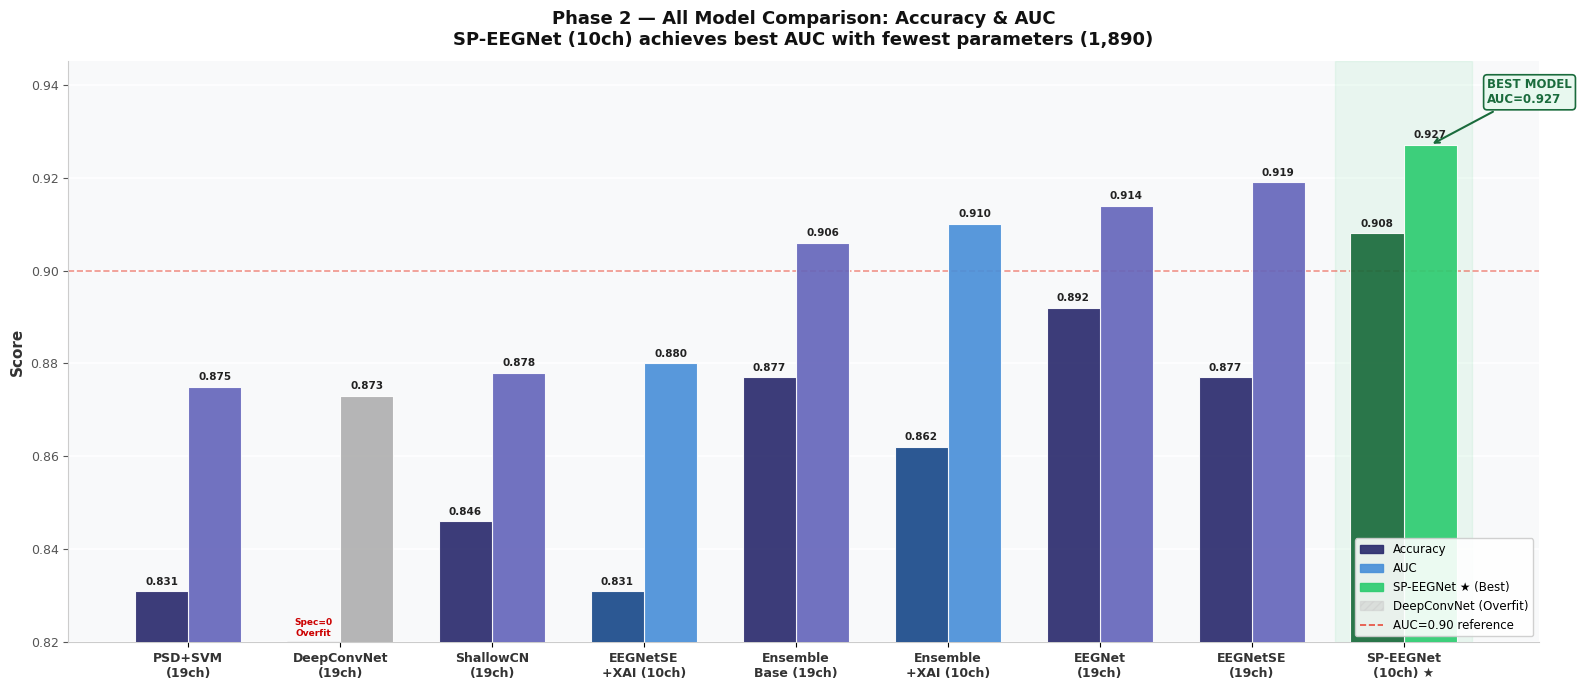

Saved as model_comparison_chart.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ─────────────────────────────────────────
# DATA — from paper Table 4
# ─────────────────────────────────────────
models = [
    'PSD+SVM\n(19ch)',
    'DeepConvNet\n(19ch)',
    'ShallowCN\n(19ch)',
    'EEGNetSE\n+XAI (10ch)',
    'Ensemble\nBase (19ch)',
    'Ensemble\n+XAI (10ch)',
    'EEGNet\n(19ch)',
    'EEGNetSE\n(19ch)',
    'SP-EEGNet\n(10ch) ★',
]

auc_vals = [
    0.875,  # PSD+SVM
    0.873,  # DeepConvNet
    0.878,  # ShallowCN
    0.880,  # EEGNetSE+XAI
    0.906,  # Ensemble base
    0.910,  # Ensemble+XAI
    0.914,  # EEGNet 19ch
    0.919,  # EEGNetSE 19ch
    0.927,  # SP-EEGNet ★
]

acc_vals = [
    0.831,  # PSD+SVM
    None,   # DeepConvNet — overfit
    0.846,  # ShallowCN
    0.831,  # EEGNetSE+XAI
    0.877,  # Ensemble base
    0.862,  # Ensemble+XAI
    0.892,  # EEGNet 19ch
    0.877,  # EEGNetSE 19ch
    0.908,  # SP-EEGNet ★
]

n = len(models)
x = np.arange(n)
w = 0.35

# ─────────────────────────────────────────
# COLORS
# ─────────────────────────────────────────
def get_colors(model_name):
    if '★' in model_name:
        return '#1a6b3c', '#2ecc71'
    elif 'Deep' in model_name:
        return '#7f7f7f', '#b0b0b0'
    elif 'XAI' in model_name or '10ch' in model_name:
        return '#1a4a8a', '#4a90d9'
    else:
        return '#2c2c6e', '#6666bb'

acc_colors = [get_colors(m)[0] for m in models]
auc_colors = [get_colors(m)[1] for m in models]

# ─────────────────────────────────────────
# FIGURE
# ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('#f8f9fa')

ax.yaxis.grid(True, color='white', linewidth=1.2, zorder=0)
ax.set_axisbelow(True)

# ─────────────────────────────────────────
# BARS
# ─────────────────────────────────────────
for i, (model, acc, auc) in enumerate(
        zip(models, acc_vals, auc_vals)):

    # AUC bar — always drawn
    ax.bar(x[i] + w/2, auc, w,
           color=auc_colors[i], alpha=0.92,
           edgecolor='white', linewidth=0.8,
           zorder=3)
    ax.text(x[i] + w/2, auc + 0.001,
            f'{auc:.3f}',
            ha='center', va='bottom',
            fontsize=7.5, fontweight='bold',
            color='#222222')

    # ACC bar
    if acc is not None:
        ax.bar(x[i] - w/2, acc, w,
               color=acc_colors[i], alpha=0.92,
               edgecolor='white', linewidth=0.8,
               zorder=3)
        ax.text(x[i] - w/2, acc + 0.001,
                f'{acc:.3f}',
                ha='center', va='bottom',
                fontsize=7.5, fontweight='bold',
                color='#222222')
    else:
        # DeepConvNet hatched bar
        ax.bar(x[i] - w/2, 0.820, w,
               color='#cccccc', alpha=0.5,
               edgecolor='#999999', linewidth=1.0,
               hatch='////', zorder=3)
        ax.text(x[i] - w/2, 0.821,
                'Spec=0\nOverfit',
                ha='center', va='bottom',
                fontsize=6.5, color='#cc0000',
                fontweight='bold')

# ─────────────────────────────────────────
# HIGHLIGHT SP-EEGNet
# ─────────────────────────────────────────
best_idx = 8
ax.axvspan(best_idx - 0.45, best_idx + 0.45,
           alpha=0.08, color='#2ecc71', zorder=1)
ax.annotate('BEST MODEL\nAUC=0.927',
            xy=(x[best_idx] + w/2, 0.927),
            xytext=(x[best_idx] + 0.55, 0.936),
            fontsize=8.5, fontweight='bold',
            color='#1a6b3c',
            arrowprops=dict(
                arrowstyle='->',
                color='#1a6b3c', lw=1.5),
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='#e8f8ef',
                edgecolor='#1a6b3c',
                linewidth=1.2))

# Reference line
ax.axhline(0.90, color='#e74c3c',
           linewidth=1.2, linestyle='--',
           alpha=0.6, zorder=2)

# ─────────────────────────────────────────
# AXES & LABELS
# ─────────────────────────────────────────
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=9,
                   fontweight='bold',
                   color='#333333')
ax.set_ylim(0.82, 0.945)
ax.set_ylabel('Score', fontsize=11,
              fontweight='bold',
              color='#333333')
ax.set_title(
    'Phase 2 — All Model Comparison: '
    'Accuracy & AUC\n'
    'SP-EEGNet (10ch) achieves best AUC '
    'with fewest parameters (1,890)',
    fontsize=13, fontweight='bold',
    color='#111111', pad=12)

# ─────────────────────────────────────────
# LEGEND
# ─────────────────────────────────────────
acc_patch = mpatches.Patch(
    color='#2c2c6e', alpha=0.92,
    label='Accuracy')
auc_patch = mpatches.Patch(
    color='#4a90d9', alpha=0.92,
    label='AUC')
best_patch = mpatches.Patch(
    color='#2ecc71', alpha=0.92,
    label='SP-EEGNet ★ (Best)')
fail_patch = mpatches.Patch(
    color='#cccccc', alpha=0.5,
    hatch='////',
    label='DeepConvNet (Overfit)')
ref_line = plt.Line2D(
    [0], [0], color='#e74c3c',
    linewidth=1.2, linestyle='--',
    label='AUC=0.90 reference')

ax.legend(
    handles=[acc_patch, auc_patch,
             best_patch, fail_patch,
             ref_line],
    loc='lower right', fontsize=8.5,
    framealpha=0.9,
    edgecolor='#cccccc')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
for spine in ['left', 'bottom']:
    ax.spines[spine].set_color('#cccccc')

ax.tick_params(axis='y', labelsize=9,
               colors='#555555')

plt.tight_layout()
plt.savefig('model_comparison_chart.png',
            dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()
print("Saved as model_comparison_chart.png")